In [42]:
import sys
import os
import numpy as np
from scipy import stats
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))

from LSM.stochastic_processes import GeometricBrownianMotion
from LSM.payoffs import VanillaPayoff, AmericanMaxCall, MaxCallFeatures, SwingSpread
from LSM.regression_bases import LaguerrePolynomials
from LSM.algorithms import LeastSquaresMonteCarlo
from LSM.binomial_tree import BinomialTreeEngine
from LSM.control_variate import *

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Benchmark Engines: BSM, BTM, FDM

In [206]:
#(1) BSM Benchmark: Black-Scholes-Merton Model for European Options using Analytical Closed Formula
def BSM(S0: float, K: float, T: float, r: float, q: float, sigma: float, option_type: str) -> float:
    """
    Returns the BSM price estimation of a European Option
    """
    option_type = option_type.lower()
    if option_type not in ['call', 'put']:
        raise ValueError("option_type must be either 'call' or 'put'.")

    d1 = (np.log(S0/K) + (r - q + 0.5*(sigma**2))*T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    if option_type == 'put':
        price = np.exp(-r*T) * K * stats.norm.cdf(-d2) - np.exp(-q*T) * S0 * stats.norm.cdf(-d1)
    else:
        price = np.exp(-q*T) * S0 * stats.norm.cdf(d1) - np.exp(-r*T) * K * stats.norm.cdf(d2)
    
    std = None # Since it is a closed form, no standard deviation

    return price, std

In [ ]:
#(2) Binomial Tree Benchmark:
def BTM(S0, K, T, r, q, sigma, n_steps, option_type = 'put'):
    payoff = VanillaPayoff(strike=K, option_type=option_type)
    Binomial_eng = BinomialTreeEngine(payoff)
    Binomial_price = Binomial_eng.pricer(S0=S0, r=r, q=q, sigma=sigma, T=T, n_steps=n_steps, american=True)
    std = None
    return Binomial_price, std

In [ ]:
#(3) Finite Difference Benchmark: 
# Import the existed Package of Finite Difference Method from QuantLib
import QuantLib as ql

def FDM(S0, K, T, r, q, sigma, option_type = "put"):
    """
    Utilize Finite-Difference Method to estimate the price of American Put Option
    FDM is directly imported from QuantLib
    """
    # Time Setting (today, expiry)
    TD = ql.Date.todaysDate()
    ql.Settings.instance().evaluationDate = TD
    expiry = TD + ql.Period(int(T * 365), ql.Days)

    # Market Information
    spot = ql.QuoteHandle(ql.SimpleQuote(S0))
    inv = ql.YieldTermStructureHandle(ql.FlatForward(TD, r, ql.Actual365Fixed())) # risk-free rate
    div = ql.YieldTermStructureHandle(ql.FlatForward(TD, q, ql.Actual365Fixed())) # dividend rate
    vol = ql.BlackVolTermStructureHandle(ql.BlackConstantVol(TD, ql.NullCalendar(), sigma, ql.Actual365Fixed()))

    # Black-Scholes-Merton Model
    bsm = ql.BlackScholesMertonProcess(spot, div, inv, vol)

    # Option Set-up
    if option_type.lower() == 'put':
        cp = ql.Option.Put
    else:
        cp = ql.Option.Call
    payoff = ql.PlainVanillaPayoff(cp, K)
    exercise = ql.AmericanExercise(TD, expiry)
    option = ql.VanillaOption(payoff, exercise)

    # Crank-Nicolson Finite-Difference Method
    tGrid = 40000
    xGrid = 1000
    fdm = ql.FdBlackScholesVanillaEngine(bsm, tGrid, xGrid)
    option.setPricingEngine(fdm)
    price = option.NPV()
    stdev = None #Note FDM has an analytical formula of pricing.

    return price, stdev


In [207]:
# Sanity check: an American call without dividend (q=0) is equivalent to a 
# European call. Compare our LSM price with the BSM European call price.
# Accuracy, runtime, (memory storage)

# Sample test parameters from Paper
S0 = 36
K = 40
r = 0.06
q = 0.0
sigma = 0.2
T = 1.0
n_steps = 50
n_paths = 10000

# BSM Sanity Check: (American Call Option = European Call)
start_bsm = time.time()
bsm_call = BSM(S0, K, T, r, q, sigma, option_type = "call")[0]
end_bsm = time.time()
print(f"BSM European Call Price: {bsm_call}.")

# American Call option price from Binomial Tree
start_BioTree = time.time()
call_payoff = VanillaPayoff(strike=K, option_type="call")
Binomial_eng = BinomialTreeEngine(call_payoff)
Binomial_call = Binomial_eng.pricer(S0=S0, r=r, q=q, sigma=sigma, T=T, n_steps=5000, american=True)
end_BioTree = time.time()
print(f"BinomialTree American Call Price {Binomial_call}")

gbm = GeometricBrownianMotion(S0=S0, r=r, q=q, sigma=sigma)
laguerre_basis = LaguerrePolynomials(degree=3)

lsm_eng = LeastSquaresMonteCarlo(
    process = gbm,
    payoff_function = call_payoff,
    basis_function=laguerre_basis
    )
start_lsm = time.time()
lsm_call = lsm_eng.pricer(T = T, n_steps = n_steps, n_paths = n_paths)[0]
end_lsm = time.time()
print(f"LSM American Call Price {lsm_call}.")
print(f"Absolute Error between BSM and LSM on Call: {abs(bsm_call - lsm_call)}")

print(f"BSM Runtime: {end_bsm - start_bsm}")
print(f"BinomialTree Runtime: {end_BioTree - start_BioTree}")
print(f"LSM Runtime: {end_lsm - start_lsm}")

BSM European Call Price: 2.1737264482268923.
BinomialTree American Call Price 2.1738096876935002
LSM American Call Price 2.2696016414700573.
Absolute Error between BSM and LSM on Call: 0.09587519324316496
BSM Runtime: 0.008365869522094727
BinomialTree Runtime: 0.2833683490753174
LSM Runtime: 0.03416013717651367


# Implementation Engines: LSM, LSM with CV, LOOLSM, LOOLSM with CV

In [209]:
# LSM Function with our own LSM Implementation
def LSM(S0, K, T, r, q, sigma, n_steps, n_paths, degree, option_type='put', control_type=None, use_loo=False):
    gbm = GeometricBrownianMotion(S0=S0, r=r, q=q, sigma=sigma)
    put_payoff = VanillaPayoff(strike=K, option_type=option_type)
    laguerre_basis = LaguerrePolynomials(degree=degree)


    lsm_engine = LeastSquaresMonteCarlo(
        process=gbm, 
        payoff_function=put_payoff, 
        basis_function=laguerre_basis
    )

    
    price, std = lsm_engine.pricer(
        T=T,
        n_steps=n_steps,
        n_paths=n_paths,
        rng=None,
        use_antithetic=False,
        control_variate=control_type,
        cache=False,
        use_loo=use_loo
    )

    return price,std

In [210]:
# LSM Function with Control Variate Method adopted
def LSM_CV(S0, K, T, r, q, sigma, n_steps, n_paths, degree, 
           option_type='put', 
           control_type = 'european_at_maturity'):
    gbm = GeometricBrownianMotion(S0=S0, r=r, q=q, sigma=sigma)
    put_payoff = VanillaPayoff(strike=K, option_type=option_type)
    laguerre_basis = LaguerrePolynomials(degree=degree)
    
    lsm_engine = LeastSquaresMonteCarlo(
        process=gbm, 
        payoff_function=put_payoff, 
        basis_function=laguerre_basis)

    price_cv, std_cv = lsm_engine.pricer(
        T=T,
        n_steps=n_steps,
        n_paths=n_paths,
        rng=np.random.default_rng(42),
        use_antithetic=False,
        control_variate=control_type,
        cache=False
    )

    return price_cv, std_cv

In [211]:
# LSM Function with Leave-One-Out (LOO) Cross-Validation Method adopted
def LSM_LOO(S0, K, T, r, q, sigma, n_steps, n_paths, degree,
            option_type='put',
            use_loo=True):
    gbm = GeometricBrownianMotion(S0=S0, r=r, q=q, sigma=sigma)
    put_payoff = VanillaPayoff(strike=K, option_type=option_type)
    laguerre_basis = LaguerrePolynomials(degree=degree)

    lsm_engine = LeastSquaresMonteCarlo(
        process=gbm,
        payoff_function=put_payoff,
        basis_function=laguerre_basis
    )

    price_loo, std_loo = lsm_engine.pricer(
        T=T,
        n_steps=n_steps,
        n_paths=n_paths,
        rng=np.random.default_rng(42),
        use_antithetic=False,
        control_variate=None,
        cache=False,
        use_loo=use_loo
    )

    return price_loo, std_loo

In [212]:
# LSM Function with Leave-One-Out (LOO) Cross-Validation Method and Control Variate Method adopted
def LOOLSM_CV(S0, K, T, r, q, sigma, n_steps, n_paths, degree,
              option_type='put', control_type='european_at_exercise', use_loo=True):
    gbm = GeometricBrownianMotion(S0=S0, r=r, q=q, sigma=sigma)
    put_payoff = VanillaPayoff(strike=K, option_type=option_type)
    laguerre_basis = LaguerrePolynomials(degree=degree)

    lsm_engine = LeastSquaresMonteCarlo(
        process=gbm,
        payoff_function=put_payoff,
        basis_function=laguerre_basis
    )

    price_loo_cv, std_loo_cv = lsm_engine.pricer(
        T=T,
        n_steps=n_steps,
        n_paths=n_paths,
        rng=np.random.default_rng(42),
        use_antithetic=False,
        control_variate=control_type,
        cache=False,
        use_loo=use_loo
    )

    return price_loo_cv, std_loo_cv

In [213]:
# A Quick Sanity Check on LSM without CV or LOO, LSM with CV, LSM with LOO for estimated price and standard deviation
# fix seed at 42
np.random.seed(42)

S0 = 100.0
r = 0.05
q = 0.0
sigma = 0.20
K = 100.0
T = 1.0
n_steps = 50
n_paths = 10000
degree = 3

# LSM without Control Variates or LOO
lsm_price, lsm_std = LSM(S0, K, T, r, q, sigma, n_steps, n_paths, degree)
print(f"LSM Price: {round(lsm_price, 6)}, Standard Deviation: {round(lsm_std, 6)}")

# LSM with Control Variates
# LSM with CV: European Option at Maturity
lsm_cv_price, lsm_cv_std = LSM(S0, K, T, r, q, sigma, n_steps, n_paths, degree, control_type='european_at_maturity')
print(f"LSM with CV at Maturity Price: {round(lsm_cv_price, 6)}, Standard Deviation: {round(lsm_cv_std, 6)}")
#LSM with CV: European Option at Exercise
lsm_CV_price, lsm_CV_std = LSM_CV(S0, K, T, r, q, sigma, n_steps, n_paths, degree, control_type='european_at_exercise')
print(f"LSM with CV at Exercise Price: {round(lsm_CV_price, 6)}, Standard Deviation: {round(lsm_CV_std, 6)}")

# LSM with LOO
lsm_loo_price, lsm_loo_std = LSM_LOO(S0, K, T, r, q, sigma, n_steps, n_paths, degree, use_loo=True)
print(f"LSM with LOO Price: {round(lsm_loo_price, 6)}, Standard Deviation: {round(lsm_loo_std, 6)}")

# LSM with both CV and LOO
lsm_loo_cv_price, lsm_loo_cv_std = LOOLSM_CV(S0, K, T, r, q, sigma, n_steps, n_paths, degree, control_type='european_at_exercise', use_loo=True)
print(f"LSM with both CV and LOO Price: {round(lsm_loo_cv_price, 6)}, Standard Deviation: {round(lsm_loo_cv_std, 6)}")

LSM Price: 6.175529, Standard Deviation: 0.071845
LSM with CV at Maturity Price: 6.158923, Standard Deviation: 0.04825
LSM with CV at Exercise Price: 6.064639, Standard Deviation: 0.003187
LSM with LOO Price: 6.120959, Standard Deviation: 0.071893
LSM with both CV and LOO Price: 6.065262, Standard Deviation: 0.003125


# Simple Comparison Table for Accuracy and Runtime under 6 Models
    # LSM / LSM_CV / LSM_LOO / BTM / FDM / BSM

In [216]:
# Simple Comparison Table for LSM Accuracy and RunTime
# Assume here it is always American Put Option
# The Benchmark must be the estimated price by a highly stable and accurate model,
    #i.e., Binominal Tree Method

def comparison(model, name: str, benchmark_price, **kwargs):
    """
    Take all existed models (BSM, LSM, ...) to compute prices
    Compare Accuracy and RunTime of our LSM with other models
    Return a Comparison Table
    """

    start = time.time()
    price,std = model(**kwargs)
    end = time.time()

    runtime = end - start
    abs_error = abs(price - benchmark_price)
    #rel_error = abs_error / benchmark_price

    Ctable = {
        "Model": name,
        "Price": price,
        "std": std,
        "Absolute Error": abs_error,
        "RunTime": runtime
    }

    return Ctable

In [218]:
#Parameters (Paper Parameter for Simple Comparison Table)
S0 = 36.0
r = 0.06
q = 0.0
sigma = 0.2
K = 40.0
T = 1.0
n_steps = 50
n_paths = 10000
cargs = dict(S0=S0, K=K, T=T, r=r, q=q, sigma=sigma, option_type = 'put')

#Benchmark
benchmark_price, _ = FDM(S0, K, T, r, q, sigma, option_type = 'put')
print(benchmark_price)

#Realization of Comparison Table
models = []

models.append(
    comparison(LSM, "Least Square Monte Carlo", benchmark_price, **cargs, n_steps=n_steps, n_paths=n_paths, degree=3,
               control_type = None))
models.append(
    comparison(LSM_CV, "LSM + Control Variate at maturity", benchmark_price, **cargs, n_steps=n_steps, n_paths=n_paths, degree=3, 
               control_type = 'european_at_maturity'))
models.append(
    comparison(LSM_CV, "LSM + Control Variate at excercise", benchmark_price, **cargs, n_steps=n_steps, n_paths=n_paths, degree=3, 
               control_type = 'european_at_exercise'))
models.append(
    comparison(LSM_LOO, "LSM + Leave One Out Cross Validation", benchmark_price, **cargs, n_steps=n_steps, n_paths=n_paths, degree=3,
               use_loo=True))
models.append(
    comparison(BTM, "Binomial Tree Model", benchmark_price, **cargs, n_steps=n_steps))
models.append(
    comparison(FDM, "Finite Difference Method(Benchmark)", benchmark_price, **cargs))
models.append(
    comparison(BSM, "Black Scholes Model", benchmark_price, **cargs)
)

#Convert into a Data Frame
df = pd.DataFrame(models)

df

4.486652881432062


,Model,Price,std,Absolute Error,RunTime
0,Least Square Monte Carlo,4.483789,0.028300,0.002863,0.236621
1,LSM + Control Variate at maturity,4.486759,0.024271,0.000106,0.069095
2,LSM + Control Variate at excercise,4.471446,0.002139,0.015207,0.062772
3,LSM + Leave One Out Cross Validation,4.487366,0.029714,0.000713,0.045326
4,Binomial Tree Model,4.484498,NaN,0.002155,0.001142
5,Finite Difference Method(Benchmark),4.486653,NaN,0.000000,1.478986
6,Black Scholes Model,3.844308,NaN,0.642345,0.003315


# Paper Table 1 Replication & Comparison 
 - Our LSM engine vs. Longstaff-Schwartz Table 1 Result

In [238]:
# (Part 1) Sanity Check: Paper Table 1 Replication & Comparison our LSM engine vs. Longstaff-Schwartz Paper Result
# Parameters: (fixed) K, r, q, n_steps, n_paths; S0, sigma, T (change in order)
fixed_param = {
    "K": 40,
    "r": 0.06,
    "q": 0.0,
    "n_steps": 50,
    "n_paths": 50000 #Note the paper uses 100,000 paths, but we make it 50,000 to reduce the time.
}

S0_list = [36, 38, 40, 42, 44]
sigma_list = [0.20, 0.40]
Time_list = [1, 2]


# Results from Table 1 (American Put Option Price by FDM)
FDM_Table1 = {
    (36, 0.20, 1): 4.478, (36, 0.20, 2): 4.840,
    (36, 0.40, 1): 7.101, (36, 0.40, 2): 8.508,
    (38, 0.20, 1): 3.250, (38, 0.20, 2): 3.745,
    (38, 0.40, 1): 6.148, (38, 0.40, 2): 7.670,
    (40, 0.20, 1): 2.314, (40, 0.20, 2): 2.885,
    (40, 0.40, 1): 5.312, (40, 0.40, 2): 6.920,
    (42, 0.20, 1): 1.617, (42, 0.20, 2): 2.212,
    (42, 0.40, 1): 4.582, (42, 0.40, 2): 6.248,
    (44, 0.20, 1): 1.110, (44, 0.20, 2): 1.690,
    (44, 0.40, 1): 3.948, (44, 0.40, 2): 5.647,
}

# Results from Table 1 (American Put Option Price by LSM)
LSM_Table1 = {
    (36, 0.20, 1): (4.472, 0.010), (36, 0.20, 2): (4.821, 0.012),
    (36, 0.40, 1): (7.091, 0.020), (36, 0.40, 2): (8.488, 0.024),
    (38, 0.20, 1): (3.244, 0.009), (38, 0.20, 2): (3.735, 0.011),
    (38, 0.40, 1): (6.139, 0.019), (38, 0.40, 2): (7.669, 0.022),
    (40, 0.20, 1): (2.313, 0.019), (40, 0.20, 2): (2.879, 0.010),
    (40, 0.40, 1): (5.308, 0.018), (40, 0.40, 2): (6.921, 0.022),
    (42, 0.20, 1): (1.617, 0.007), (42, 0.20, 2): (2.206, 0.010),
    (42, 0.40, 1): (4.588, 0.017), (42, 0.40, 2): (6.243, 0.021),
    (44, 0.20, 1): (1.118, 0.007), (44, 0.20, 2): (1.675, 0.009),
    (44, 0.40, 1): (3.957, 0.017), (44, 0.40, 2): (5.622, 0.021), 
}

# Table 1 Replication using our own LSM engine
def table1_replication(LSM_engine, FDM_engine, iterations = 25, seed = 42):
    """
    Here we test our own LSM engine to replicate Table 1 from LongStaff-Schwartz Paper by iterations times,
        take "average price, standard deviation" and compare with Table 1 from paper
    Fix Seed at 42
    Input:
        LSM_engine: our own implementation of LSM algorithm
            LSM(S0, K, T, r, q, sigma, n_steps, n_paths, degree, option_type='put')
        FDM_engine: the imported FDM algorithm from QuantLib
             FDM(S0, K, T, r, q, sigma, option_type = "put")
        iterations: as it states, the iteration times to reduce randomness
        seed: randomness
    Return:
        dataframe: a DataFrame with the same format of Paper Table 1
    """
    # fixed parameters
    K = fixed_param["K"]
    r = fixed_param["r"]
    q = fixed_param["q"]
    n_steps = fixed_param["n_steps"]
    n_paths = fixed_param["n_paths"]
    # storage list
    results = [] # Replication Table 1
    comparison = [] # Comparison Table

    # simulation
    for S0 in S0_list:
        for sigma in sigma_list:
            for T in Time_list:
                N_steps = n_steps * T
                feature = (S0, sigma, T)

                # LSM engine iterations
                lsm_prices = []
                lsm_std = []
                for i in range(iterations):
                    np.random.seed(seed + i)
                    price, std = LSM_engine(
                        S0 = S0, K = K, T = T, r = r, q = q, 
                        sigma = sigma, degree = 3, n_steps = N_steps, n_paths = n_paths)
                    lsm_prices.append(price)
                    lsm_std.append(std)

                lsm_price = np.mean(lsm_prices)
                lsm_se = np.mean(lsm_std)

                # FDM engine Evaluation 
                fdm_price, _ = FDM_engine(S0 = S0, K = K, T = T, r = r, q = q, sigma = sigma)

                # BSM European Put Option Price
                BSM_price, _ = BSM(S0, K, T, r, q, sigma, option_type = "put")

                # Early Exercise Value: AmericanPut - EuropeanPut
                fdm_early_val = fdm_price - BSM_price
                lsm_early_val = lsm_price - BSM_price

                paper_lsm_val, paper_lsm_se = LSM_Table1[feature]

                # Accuracy Comparison
                diff_price_val = lsm_price - fdm_price
                diff_early_val =  lsm_early_val - fdm_early_val
                within_2se = abs(diff_price_val) <= 2 * lsm_se

                results.append({
                    "S0": S0,
                    "sigma": sigma,
                    "T": T,
                    #FDM vals
                    "Finite Difference American": fdm_price,
                    "Closed form European": BSM_price,
                    "Early exercise Value (FDM)": fdm_early_val,
                    #LSM simulated vals
                    "Simulated American": lsm_price,
                    "(s.e.)": lsm_std,
                    "Closed form European": BSM_price,
                    "Early exercise Value (LSM)": lsm_early_val,
                    # Difference between two methods
                    "Difference in early exercise value": diff_early_val
                })

                comparison.append({
                    "S0": S0,
                    "sigma": sigma,
                    "T": T,
                    # FDM benchmark
                    "FDM Price": round(fdm_price, 3),
                    "FDM early exercise": round(fdm_early_val, 3),
                    # LSM engine
                    "LSM Price": round(lsm_price, 3),
                    "LSM s.e.": round(lsm_se, 3),
                    "LSM early exercise": round(lsm_early_val, 3),
                    # Paper LSM
                    "Paper LSM": paper_lsm_val,
                    "Paper s.e.": paper_lsm_se,
                    # Accuracy
                    "Difference in Vals": diff_price_val,
                    "Difference in Early Exercise": diff_early_val,
                    "Whether within 2 s.e.": "yes" if within_2se else "no"
                })
    return pd.DataFrame(comparison), pd.DataFrame(results)
                    
# generate Comparison Table between our replication and original Table 1
if __name__ == "__main__":
    import time

    start = time.time()
    dataframe = table1_replication(LSM, FDM, iterations = 25)[0]
    replication = table1_replication(LSM, FDM, iterations = 25)[1]
    elapsed = time.time() - start

    print(f"Runtime: {elapsed:.1f}s")
    print("\n---------------- Table 1 Replication Comparison ----------------")
    print(dataframe.to_string(index = False))

    print("\n---------------- Summary ----------------")
    print(f"Mean |Difference in Vals|: {dataframe['Difference in Vals'].abs().mean():.4f}")
    print(f"Max |Difference in Vals|: {dataframe['Difference in Vals'].abs().max():.4f}")
    within = (dataframe["Whether within 2 s.e."] == 'yes').sum()
    print(f"Whether within 2 s.e.: {within}/{len(dataframe)}")
    print(f"|accuracy| < 0.03: {(dataframe['Difference in Vals'].abs() < 0.03).sum()}/{len(dataframe)}")

    dataframe.to_csv("Table1_replication_comparison.csv", index = False)
    replication.to_csv("Table1_replication_summary.csv", index = False)
    

Runtime: 197.2s

---------------- Table 1 Replication Comparison ----------------
 S0  sigma  T  FDM Price  FDM early exercise  LSM Price  LSM s.e.  LSM early exercise  Paper LSM  Paper s.e.  Difference in Vals  Difference in Early Exercise Whether within 2 s.e.
 36    0.2  1      4.487               0.642      4.475     0.013               0.631      4.472       0.010           -0.011417                     -0.011417                   yes
 36    0.2  2      4.848               1.085      4.840     0.016               1.077      4.821       0.012           -0.008285                     -0.008285                   yes
 36    0.4  1      7.109               0.398      7.100     0.027               0.389      7.091       0.020           -0.009037                     -0.009037                   yes
 36    0.4  2      8.514               0.814      8.506     0.032               0.806      8.488       0.024           -0.008524                     -0.008524                   yes
 38    0.2  1

# Random Parameter Sampling Benchmark

In [237]:
#(Part 2) Random Parameter Sampling (note n_paths = 15000 here)
def random_benchmark_test(LSM_engine, FDM_engine, option_type = 'put', n_samples = 200, iterations = 25, seed = 42):
    """
    Here we run random parameter sampling benchmark on our LSM engine
        Compare LSM versus FDM across all randomly generated parameters (with K fixed at 100)
    Input:
        LSM_engine: our own implementation of LSM algorithm
            LSM(S0, K, T, r, q, sigma, n_steps, n_paths, option_type='put')
        FDM_engine: the imported FDM algorithm from QuantLib as comparison
            FDM(S0, K, T, r, q, sigma, option_type = "put")
        iterations: as it states, the iteration times to reduce randomness
        parameters: S0, K, T, r, q, sigma, (n_steps, n_paths)
    Return:
        dataframe: a DataFrame similar to Table 1
    """
    # Parameters
    np.random.seed(seed)
    strike = 100 # We fix K at 100 for convenience (ITM, ATM, OTM)
    stock = np.random.uniform(60, 140, n_samples) # from deep ITM to deep OTM
    volatility = np.random.uniform(0.050, 0.60, n_samples)
    duration = np.random.uniform(0.25, 3.0, n_samples)
    interest = np.random.uniform(0.01, 0.15, n_samples)
    dividend = np.random.uniform(0.00, 0.08, n_samples)

    results = []

    for indx in range(n_samples):
        n_steps = int(50 * duration[indx])
        S0 = round(stock[indx], 3)
        K = strike
        sigma = round(volatility[indx], 4)
        T = round(duration[indx], 4)
        r = round(interest[indx], 4)
        q = round(dividend[indx], 4)

        # LSM without Control Variate Iterations
        lsm_prices = []
        lsm_std = []
        for i in range(iterations):
            np.random.seed(seed*100 + indx*10 + i)
            price, std = LSM_engine(
                S0 = S0, K = K, T = T, r = r, q = q, option_type = option_type,
                sigma = sigma, degree = 3, n_steps = n_steps, n_paths = 15000)
            lsm_prices.append(price)
            lsm_std.append(std)
        lsm_price = np.mean(lsm_prices)
        lsm_se = np.mean(lsm_std)

        # FDM Evaluation
        fdm_price, _ = FDM_engine(S0 = S0, K = K, T = T, r = r, q = q, option_type = option_type, sigma = sigma)
        
        # BSM on European Options
        bsm_price, _ = BSM(S0, K, T, r, q, sigma, option_type = option_type)

        accuracy = lsm_price - fdm_price
        if lsm_se > 1e-6:
            within_2se = abs(accuracy) <= 2*lsm_se
        else:
            within_2se = abs(accuracy) < 0.001 # LSM std error close to zero but LSM price within a tenth of a cent of the FDM price
        dist_se = abs(accuracy)/(lsm_se + 1e-6)
        within_2se = abs(accuracy) <= (2*lsm_se)
        # if S0/K < 1:
        #     moneyness = "ITM"
        # elif S0/K == 1:
        #     moneyness = "ATM"
        # else:
        #     moneyness = "OTM"
        moneyness = round(S0 / K , 3)

        results.append({
            "S0": S0,
            "K": K,
            "sigma": sigma,
            "T": T,
            "r": r,
            "q": q,
            "Moneyness": moneyness,
            "FDM price": round(fdm_price, 3),
            "LSM price": round(lsm_price, 3),
            "LSM s.e.": round(lsm_se, 4),
            "BSM price": round(bsm_price, 3),
            "Early Exercise (FDM)": round(fdm_price - bsm_price, 4),
            "Early Exercise (LSM)": round(lsm_price - bsm_price, 4),
            "Accuracy": round(accuracy, 3),
            "Distance to se": round(dist_se, 3),
            "Within 2se": "yes" if within_2se else "no"
        })

        if (indx + 1) % 50 == 0:
            print(f" {indx+1} / {n_samples} done...")

    results = pd.DataFrame(results)
    if option_type == 'put':
        results['Moneyness_Bucket'] = pd.cut(results['Moneyness'], 
                                             bins=[0, 0.9, 1.1, 2.0], 
                                            labels=['ITM (Put)', 'ATM', 'OTM (Put)'])
    else:
        results['Moneyness_Bucket'] = pd.cut(results['Moneyness'], 
                                             bins=[0, 0.9, 1.1, 2.0], 
                                            labels=['OTM (Call)', 'ATM', 'ITM (Call)'])

    return results.sort_values(by=['Moneyness', 'T'], ascending=[False, False])
    


# Table Return
if __name__ == "__main__":
    import time

    start = time.time()
    df = random_benchmark_test(LSM, FDM, option_type = 'put', n_samples = 500, iterations = 10, seed = 42)
    elapsed = time.time() - start

    print(f"\n Total Cases: {len(df)}")
    print(f"Runtime: {elapsed:.1f}s")
    print(f"Mean |Accuracy|: {df['Accuracy'].abs().mean():.4f}")
    print(f"Max |Accuracy|: {df['Accuracy'].abs().max():.4f}")
    within = (df['Within 2se'] == 'yes').sum()
    print(f"within 2 s.e.: {within}/{len(df)}")
    small = (df["Accuracy"].abs() < 0.05).sum()
    print(f"|Accuracy| < 0.05: {small}/{len(df)}")

    df.to_csv("random_benchmark_test.csv", index = False)

    summary = df.groupby('Moneyness_Bucket', observed=False).agg({
        'Accuracy': ['mean', 'std'],
        'Within 2se': lambda x: (x == 'yes').mean()
    })
    print("\n", summary)

 20 / 500 done...
 40 / 500 done...
 60 / 500 done...
 80 / 500 done...
 100 / 500 done...
 120 / 500 done...
 140 / 500 done...
 160 / 500 done...
 180 / 500 done...
 200 / 500 done...
 220 / 500 done...
 240 / 500 done...
 260 / 500 done...
 280 / 500 done...
 300 / 500 done...
 320 / 500 done...
 340 / 500 done...
 360 / 500 done...
 380 / 500 done...
 400 / 500 done...
 420 / 500 done...
 440 / 500 done...
 460 / 500 done...
 480 / 500 done...
 500 / 500 done...

 Total Cases: 500
Runtime: 1406.8s
Mean |Accuracy|: 0.0257
Max |Accuracy|: 0.1480
within 2 s.e.: 430/500
|Accuracy| < 0.05: 411/500

                   Accuracy           Within 2se
                      mean       std   <lambda>
Moneyness_Bucket                               
ITM (Put)         0.000566  0.038385   0.656566
ATM               0.001047  0.040470   1.000000
OTM (Put)         0.012328  0.034907   0.989744


In [239]:
#(Part 2) Random Parameter Sampling (Summary about the inaccurate cases)
df_sorted = df.sort_values("Accuracy", ascending=False)
print(df_sorted[["S0", "sigma", "T", "r", "q", 
                  "FDM price", "LSM price", "Accuracy", "Moneyness", "Moneyness_Bucket"]].head(10))

          S0   sigma       T       r       q  FDM price  LSM price  Accuracy  \
325  119.032  0.5559  1.1765  0.0842  0.0764     15.918     16.053     0.135   
216   86.032  0.5068  0.4765  0.0181  0.0664     22.036     22.166     0.130   
71    75.897  0.4810  0.8924  0.0335  0.0416     30.252     30.372     0.121   
498  137.952  0.5726  1.2944  0.0180  0.0785     16.789     16.908     0.119   
466   82.857  0.4455  2.9372  0.0358  0.0316     33.726     33.841     0.116   
307   85.837  0.5591  2.4548  0.0359  0.0494     37.517     37.629     0.112   
245  134.265  0.5448  1.9721  0.0774  0.0417     16.379     16.489     0.110   
207  113.080  0.4954  1.4762  0.0402  0.0687     19.535     19.641     0.106   
210  103.899  0.4681  1.4220  0.0313  0.0603     21.184     21.287     0.104   
13    76.987  0.5263  0.3584  0.0126  0.0111     26.006     26.106     0.100   

     Moneyness Moneyness_Bucket  
325      1.190        OTM (Put)  
216      0.860        ITM (Put)  
71       0.759   

# Visualization of random benchmark test results

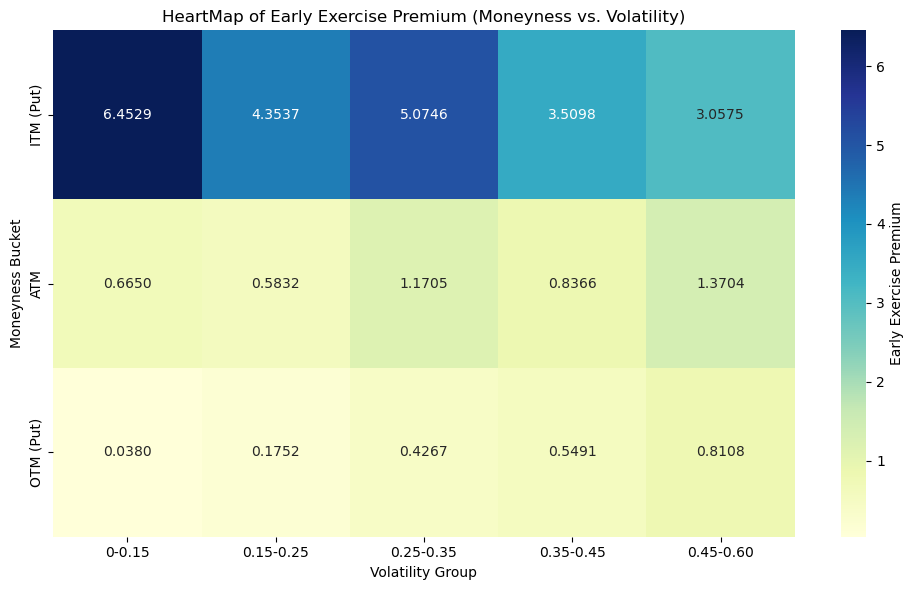

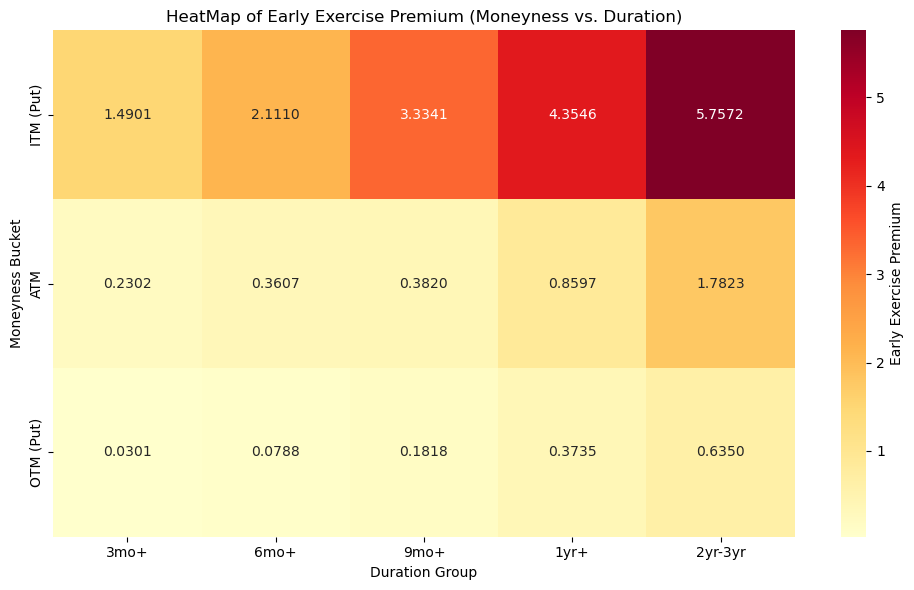

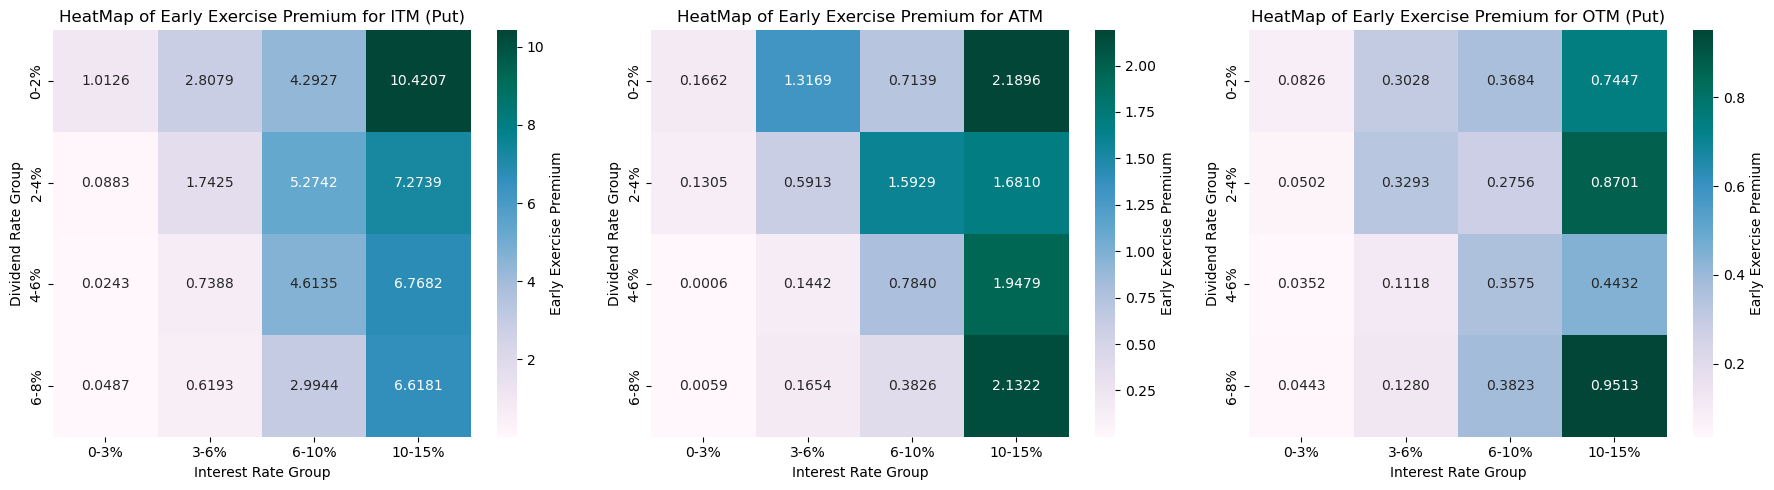

In [240]:
# Visualization of random benchmark test results - e.g. how the early exercise premium changes across moneyness and duration    
def moneyness_vol_heat_map(df):
    """
    Visualize how the early exercise premium changes across moneyness and volatility
    Input:
        df: the DataFrame generated from random_benchmark_test function
    Return:
        a heat map of early exercise premium across moneyness and duration
    """
    df['Volatility_group'] = pd.cut(df['sigma'], bins=[0, 0.15, 0.25, 0.30, 0.45, 0.60], labels=['0-0.15', '0.15-0.25', '0.25-0.35', '0.35-0.45', '0.45-0.60'])
    heatmap_data = df.groupby(['Moneyness_Bucket', 'Volatility_group'])['Early Exercise (LSM)'].mean().unstack()
    order = ["ITM (Put)", "ATM", "OTM (Put)"]
    heatmap_data = heatmap_data.reindex(order)

    plt.figure(figsize=(10, 6))
    sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="YlGnBu", cbar_kws={'label': 'Early Exercise Premium'})
    plt.title('HeartMap of Early Exercise Premium (Moneyness vs. Volatility)')
    plt.xlabel('Volatility Group')
    plt.ylabel('Moneyness Bucket')
    plt.tight_layout()
    plt.show()

def moneyness_duration_heat_map(df):
    """
    Visualize how the early exercise premium changes across moneyness and duration
    Input:
        df: the DataFrame generated from random_benchmark_test function
    Return:
        a heat map of early exercise premium across moneyness and duration
    """
    df['Duration_group'] = pd.cut(df['T'], bins=[0.24, 0.5, 0.75, 1.0, 2.0, 3.0], labels=['3mo+', '6mo+', '9mo+', '1yr+', '2yr-3yr'])
    heatmap_data = df.groupby(['Moneyness_Bucket', 'Duration_group'])['Early Exercise (LSM)'].mean().unstack()
    order = ["ITM (Put)", "ATM", "OTM (Put)"]
    heatmap_data = heatmap_data.reindex(order)

    plt.figure(figsize=(10, 6))
    sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="YlOrRd", cbar_kws={'label': 'Early Exercise Premium'})
    plt.title('HeatMap of Early Exercise Premium (Moneyness vs. Duration)')
    plt.xlabel('Duration Group')
    plt.ylabel('Moneyness Bucket')
    plt.tight_layout()
    plt.show()

def interest_divided_heat_map(df):
    """
    Visualize how the early exercise premium changes across interest rate and dividend rate
    Input:
        df: the DataFrame generated from random_benchmark_test function
    Return:
        a heat map of early exercise premium across interest rate and dividend rate
    """
    df['interest_group'] = pd.cut(df['r'], bins=[0.00, 0.03, 0.06, 0.10, 0.15], labels=['0-3%', '3-6%', '6-10%', '10-15%'])
    df['dividend_group'] = pd.cut(df['q'], bins=[0.00, 0.02, 0.04, 0.06, 0.08], labels=['0-2%', '2-4%', '4-6%', '6-8%'])
    order_r = ['0-3%', '3-6%', '6-10%', '10-15%']
    order_q = ['0-2%', '2-4%', '4-6%', '6-8%']
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, bucket in zip(axes, ['ITM (Put)', 'ATM', 'OTM (Put)']):
        subset = df[df['Moneyness_Bucket'] == bucket]
        heatmap_data = subset.groupby(['dividend_group', 'interest_group'])['Early Exercise (LSM)'].mean().unstack()
        heatmap_data = heatmap_data.reindex(index=order_q, columns=order_r)
        sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="PuBuGn", cbar_kws={'label': 'Early Exercise Premium'}, ax=ax)
        ax.set_title(f'HeatMap of Early Exercise Premium for {bucket}')
        ax.set_xlabel('Interest Rate Group')
        ax.set_ylabel('Dividend Rate Group')
    plt.tight_layout()
    plt.show()
#Note that the problem with HeatMap of r vs. q could be due to the limited number of samples in each bucket, which leads to high variance in the average early exercise premium.
#We may fix this by increasing the sample size from 200 to 2000 but this causes a significant increase in runtime, so we keep it as it is for now and just interpret the heatmap with caution.
#Also, the white blocks in the heatmap for ATM case are because of the limited sample size as well - we don't have certain data generated

if __name__ == "__main__":
    moneyness_vol_heat_map(df)
    moneyness_duration_heat_map(df)
    interest_divided_heat_map(df)

# Moneyness Testing: Compare Trend & Accuracy across ITM, ATM, OTM 

In [222]:
#(Part 3) Moneyness Testing - Compare Accuracy across ITM, ATM, OTM options
def moneyness_test(df_random):
    """
    Extract ATM/ITM/OTM cases from the results of (Part 2) random benchmark test
    Show the early exercise premium across moneyness levels
    Input:
        df: the DataFrame generated from random_benchmark_test function
    Return:
        summary: a summary of accuracy across moneyness
    """
    # Group by moneyness for 
    def classify(m):
        if m < 0.75:
            return "Deep ITM"
        elif 0.75 <= m < 0.90:
            return "ITM"
        elif 0.90 <= m < 0.98:
            return "Slight ITM"
        elif 0.98 <= m <= 1.02:
            return "ATM"
        elif 1.02 < m <= 1.10:
            return "Slight OTM"
        elif 1.10 < m <= 1.25:
            return "OTM"
        else:
            return "Deep OTM"
        
    df = df_random.copy()
    df["Moneyness Level"] = (df["S0"] / 100).apply(classify) # We already fix K at 100

    # Group by moneyness level and summarize accuracy
    summary = df.groupby("Moneyness Level").agg(
        Count = ("LSM price", "count"),
        LSM_mean = ("LSM price", "mean"),
        FDM_mean = ("FDM price", "mean"),
        EarlyEx_mean = ("Early Exercise (LSM)", "mean"),
        EarlyEx_max = ("Early Exercise (LSM)", "max"),
        EarlyEx_min = ("Early Exercise (LSM)", "min"),
        Accuracy_mean = ("Accuracy", "mean"),
        Accuracy_std = ("Accuracy", "std"),
        Accuracy_max = ("Accuracy", "max"),
        Within_2se = ("Within 2se", lambda x: (x == 'yes').sum())
    ).round(4)

    order = ["Deep ITM", "ITM", "Slight ITM", "ATM", "Slight OTM", "OTM", "Deep OTM"]
    summary = summary.reindex(o for o in order if o in summary.index)

    return df, summary

if __name__ == "__main__":
    # We already have df from the random benchmark test, we can directly run the moneyness test
    df_detail, df_summary = moneyness_test(df)

    print("\n---------------- Moneyness Test Summary ----------------")
    print(df_summary.to_string())

    df_summary.to_csv("moneyness_test_summary.csv")
    df_detail.to_csv("moneyness_test_detail.csv", index = False)


---------------- Moneyness Test Summary ----------------
                 Count  LSM_mean  FDM_mean  EarlyEx_mean  EarlyEx_max  EarlyEx_min  Accuracy_mean  Accuracy_std  Accuracy_max  Within_2se
Moneyness Level                                                                                                                          
Deep ITM           108   34.7231   34.7335        5.6172      17.8224      -0.1027        -0.0104        0.0562         0.140          51
ITM                 89   22.0551   22.0674        2.8216      16.9448      -0.1152        -0.0124        0.0683         0.136          63
Slight ITM          36   15.9351   15.9618        1.6986       5.7127      -0.0139        -0.0268        0.0682         0.177          32
ATM                 26   12.0222   12.0010        0.9471       3.8400       0.0286         0.0212        0.0598         0.209          24
Slight OTM          46   11.3528   11.3528        0.4493       2.9848      -0.0982         0.0001        0.0706   

In [241]:
df_detail, df_summary = moneyness_test(df)
print((df_detail["S0"] / 100).describe())
print(df_detail["Moneyness Level"].value_counts())

count    500.000000
mean       0.998849
std        0.238951
min        0.604050
25%        0.793022
50%        1.010530
75%        1.204900
max        1.394370
Name: S0, dtype: float64
Moneyness Level
Deep ITM      108
OTM            98
Deep OTM       97
ITM            89
Slight OTM     46
Slight ITM     36
ATM            26
Name: count, dtype: int64


# Edge Case Testing

Running Deep ITM, S0...
Running Deep OTM, S0...
Running Very High Volatility, sigma...
Running Very Low Volatility, sigma...
Running Very Long Duration, T...
Running Very Short Duration, T...
Running Very High Interest, r...
Running Very Low Interest, r...
Running Very High Dividend, q...
Running Very Low Dividend, q...
Case
Deep ITM, S0                   3.0817
Deep OTM, S0                   0.0450
Very High Dividend, q          0.0346
Very High Interest, r          4.6253
Very High Volatility, sigma    0.9004
Very Long Duration, T          3.8571
Very Low Dividend, q           1.2085
Very Low Interest, r          -0.0290
Very Low Volatility, sigma     3.1186
Very Short Duration, T         0.4106
Name: Early Exercise (LSM), dtype: float64


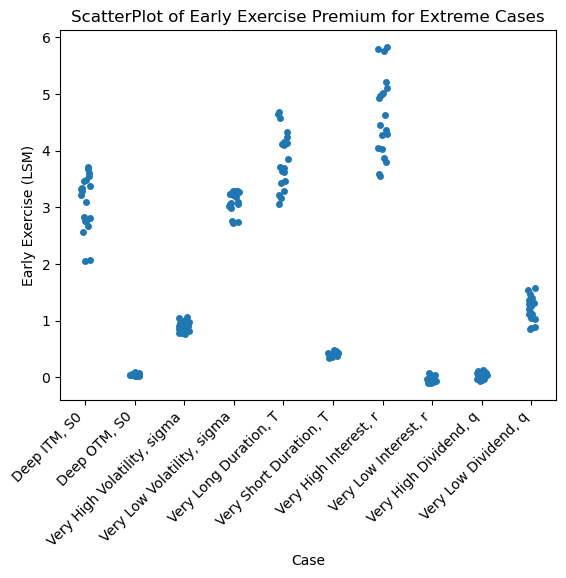

In [ ]:
#(Part 4) Edge Cases Testing - Compare Accuracy across different parameters (e.g. very high volatility, very long duration, etc.)
def edge_case_test(LSM_engine, FDM_engine, option_type = 'put', n_samples = 200, iterations = 25, seed = 42):
    """
    Here we test the stability of LSM_engines with extreme paramters,
        and how extreme parameters affect the price of American Options estimated by our LSM engine
        and also how the early exercise premium changes 
        Note that for each paramter, we will fix other paramters for simplification.
    Inputs:
        LSM_engine: LSM(S0, K, T, r, q, sigma, n_steps, n_paths, option_type = 'put')
        FDM_engine: FDM(S0, K, T, r, q, sigma, option_type = 'put')
        iterations: repeating times to reduce randomness
        parameters: S0, K, T, r, q, sigma, n_steps, n_paths, 'put'
    Returns:
        dataframe: a DataFrame summarizing the results of edge cases testing
            pair up high and low values for each parameter, and compare the price, early exercise premium, accuracy, etc.
    """
    np.random.seed(seed)
    K = 100

    edge_cases = {
        "Deep ITM, S0":{
            "fixed": {"sigma": 0.30, "T": 1, "r": 0.05, "q": 0.02}, 
            "vary": {"S0": (50, 70)}},
        "Deep OTM, S0": {
            "fixed": {"sigma": 0.30, "T": 1, "r": 0.05, "q": 0.02}, 
            "vary": {"S0": (130, 150)}},
        "Very High Volatility, sigma": {
            "fixed": {"S0": 80, "T": 1, "r": 0.05, "q": 0.02}, 
            "vary": {"sigma": (0.30, 0.50)}},
        "Very Low Volatility, sigma": {
            "fixed": {"S0": 80, "T": 1, "r": 0.05, "q": 0.02}, 
            "vary": {"sigma": (0.05, 0.15)}},
        "Very Long Duration, T": {
            "fixed": {"S0": 80, "sigma": 0.30, "r": 0.05, "q": 0.02},
            "vary": {"T": (3.0, 5.0)}},
        "Very Short Duration, T"   :{
            "fixed": {"S0": 80, "sigma": 0.30, "r": 0.05, "q": 0.02},
            "vary": {"T": (0.10, 0.25)}},
        "Very High Interest, r": {
            "fixed": {"S0": 80, "sigma": 0.30, "T": 1, "q": 0.02},
            "vary": {"r": (0.10, 0.15)}},
        "Very Low Interest, r": {
            "fixed": {"S0": 80, "sigma": 0.30, "T": 1, "q": 0.02},
            "vary": {"r": (0.00, 0.01)}},
        "Very High Dividend, q": {
            "fixed": {"S0": 80, "sigma": 0.30, "T": 1, "r": 0.05}, 
            "vary": {"q": (0.07, 0.10)}},
        "Very Low Dividend, q": {
            "fixed": {"S0": 80, "sigma": 0.30, "T": 1, "r": 0.05}, 
            "vary": {"q": (0.00, 0.03)}}
    }

    results = []

    for case, params in edge_cases.items():
        print(f"Running {case}...")

        for idx in range(n_samples):
            for var, (low, high) in params["vary"].items():
                parameters = params["fixed"].copy()
                parameters[var] = round(np.random.uniform(low, high), 4)
                S0 = parameters["S0"]
                sigma = parameters["sigma"]
                T = parameters["T"]
                r = parameters["r"]
                q = parameters["q"]
                n_steps = max(int(50 * T), 10)

                # LSM Iterations
                lsm_prices = []
                for i in range(iterations):
                    np.random.seed(seed*100 + idx*10 + i)
                    price, std = LSM_engine(
                        S0 = S0, K = K, T = T, r = r, q = q, option_type = option_type,
                        sigma = sigma, degree = 3, n_steps = n_steps, n_paths = 15000
                    )
                    lsm_prices.append(price)
                
                lsm_price = np.mean(lsm_prices)
                lsm_se = np.std(lsm_prices, ddof=1)

                # FDM Evaluation
                fdm_price, _ = FDM_engine(S0 = S0, K = K, T = T, r = r, q = q, option_type = option_type, sigma = sigma)

                # BSM on European Option
                bsm_price, _ = BSM(S0, K, T, r, q, sigma, option_type)

                # Variables
                accuracy = lsm_price - fdm_price #use fdm as benchmark
                if lsm_se > 1e-6:
                    within_2se = abs(accuracy) <= 2*lsm_se
                else:
                    within_2se = abs(accuracy) < 0.001
                dist_se = abs(accuracy) / (lsm_se + 1e-6)
                results.append({
                    "Case": case,
                    "S0": S0,
                    "sigma": sigma,
                    "T": T,
                    "r": r,
                    "q": q,
                    "LSM price": round(lsm_price, 3),
                    "BSM price": round(bsm_price, 3),
                    "LSM s.e.": round(lsm_se, 4),
                    "Early Exercise (LSM)": round(lsm_price - bsm_price, 4),
                    "Accuracy vs. FDM": round(accuracy, 3),
                    "Distance to se": round(dist_se, 3),
                    "Within 2se": "yes" if within_2se else "no"
                })
    results = pd.DataFrame(results)
    return results

# Table Return
if __name__ == "__main__":
    import time

    start = time.time()
    edge_results = edge_case_test(LSM, FDM, option_type = 'put', n_samples = 20, iterations = 10, seed = 42)
    elapsed = time.time() - start

# Summary of Edge Cases Testing
    print(edge_results.groupby("Case")["Early Exercise (LSM)"].mean().round(4))

# ScatterPlots of Edge Cases Testing on High vs. Low Parameters
    sns.stripplot(data = edge_results, x = "Case", y = "Early Exercise (LSM)", dodge = True)
    plt.xticks(rotation=45, ha='right')
    plt.title("ScatterPlot of Early Exercise Premium for Extreme Cases")
    edge_results.to_csv("edge_case_test.csv", index = False)

# Comparison between LSM & LSM_CV using European Option at Exercise
    # Variance Reduction

In [191]:
# (Part 5) LSM with Control Variate - Compare price and early exercise premium under LSM with and without Control Variate - Variance Comparison
def control_variate_compare(LSM_engine, LSM_CV_engine, option_type = 'put', n_samples = 200, iterations = 25, seed = 42):
    """
    Here we run random parameter sampling benchmark on our LSM engine
        Compare LSM with Control Variate versus LSM without CV across all randomly generated parameters (with K fixed at 100)
    Input:
        LSM_engine: our own implementation of LSM 
            LSM(S0, K, T, r, q, sigma, n_steps, n_paths, option_type='put')
        LSM_CV_engine: implementation of LSM algorithm with Control Variate
            LSM_CV(S0, K, T, r, q, sigma, n_steps, n_paths, degree, option_type='put', control_type = 'european_at_maturity')
        iterations: as it states, the iteration times to reduce randomness
        parameters: S0, K, T, r, q, sigma, (n_steps, n_paths)
        Note that the Control Variate is European Option
    Return:
        dataframe: a DataFrame compare the price, early exercise premium, variance, etc. between LSM with and without Control Variate
    """
    # Parameters
    np.random.seed(seed)
    strike = 100 # We fix K at 100 for convenience (ITM, ATM, OTM)
    stock = np.random.uniform(60, 140, n_samples) # from deep ITM to deep OTM
    volatility = np.random.uniform(0.050, 0.60, n_samples)
    duration = np.random.uniform(0.25, 3.0, n_samples)
    interest = np.random.uniform(0.01, 0.15, n_samples)
    dividend = np.random.uniform(0.00, 0.08, n_samples)

    results = []

    for indx in range(n_samples):
        n_steps = int(50 * duration[indx])
        S0 = round(stock[indx], 3)
        K = strike
        sigma = round(volatility[indx], 4)
        T = round(duration[indx], 4)
        r = round(interest[indx], 4)
        q = round(dividend[indx], 4)

        # LSM without Control Variate Iterations
        lsm_prices = []
        lsm_std = []
        for i in range(iterations):
            np.random.seed(seed*100 + indx*10 + i)
            price, std = LSM_engine(
                S0 = S0, K = K, T = T, r = r, q = q, option_type = option_type,
                sigma = sigma, degree = 3, n_steps = n_steps, n_paths = 15000)
            lsm_prices.append(price)
            lsm_std.append(std)
        lsm_price = np.mean(lsm_prices)
        lsm_se = np.mean(lsm_std)

        # LSM with Control Variate Iterations - CV: European Option at exercise
        lsm_cv_prices = []
        lsm_cv_std = []
        for j in range(iterations):
            np.random.seed(seed*100 + indx*10 + j + 1000)
            price_cv, std_cv = LSM_CV_engine(
                S0, K, T, r, q, sigma, n_steps, n_paths=15000, degree=3, option_type='put', control_type = 'european_at_exercise'
            )
            lsm_cv_prices.append(price_cv)
            lsm_cv_std.append(std_cv)
        lsm_cv_price = np.mean(lsm_cv_prices)
        lsm_cv_se = np.mean(lsm_cv_std)

        # BSM on European Options
        bsm_price, _ = BSM(S0, K, T, r, q, sigma, option_type = option_type)

        moneyness = round(S0 / K , 3)

        results.append({
            "T": T,
            "Moneyness": round(moneyness, 3),
            "LSM price": round(lsm_price, 3),
            "LSM s.e.": round(lsm_se, 6),
            "LSM Early Exercise Premium": round(lsm_price - bsm_price, 4),
            "LSM CV price": round(lsm_cv_price, 3),
            "LSM CV s.e.": round(lsm_cv_se, 6),
            "LSM CV Early Exercise Premium": round(lsm_cv_price - bsm_price, 4),
            "Difference in Price": round(lsm_price - lsm_cv_price, 3),
            "Difference in Early Exercise Premium": round((lsm_price - bsm_price) - (lsm_cv_price - bsm_price), 4),
            "Variance Reduction (%)": round((lsm_se**2 - lsm_cv_se**2) / (lsm_se**2 + 1e-6) * 100, 2),
            "Whether LSM CV has variance reduction": "yes" if (lsm_cv_se**2) < (lsm_se**2) else "no"
        })

        if (indx + 1) % 100 == 0:
            print(f" {indx+1} / {n_samples} done...")

    results = pd.DataFrame(results)
    if option_type == 'put':
        results['Moneyness_Bucket'] = pd.cut(results['Moneyness'], 
                                             bins=[0, 0.9, 1.1, 2.0], 
                                            labels=['ITM (Put)', 'ATM', 'OTM (Put)'])
    else:
        results['Moneyness_Bucket'] = pd.cut(results['Moneyness'], 
                                             bins=[0, 0.9, 1.1, 2.0], 
                                            labels=['OTM (Call)', 'ATM', 'ITM (Call)'])
    return results.sort_values(by=['Moneyness', 'T'], ascending=[False, False])
        
# Table Return
if __name__ == "__main__":
    import time

    start = time.time()
    cv_comparison_df = control_variate_compare(LSM, LSM_CV, option_type = 'put', n_samples = 1000, iterations = 10, seed = 42)
    elapsed = time.time() - start

    print(f"\n Total Cases: {len(cv_comparison_df)}")
    print(f"Runtime: {elapsed:.1f}s")
    print(f"Mean |Difference in Price|: {cv_comparison_df['Difference in Price'].abs().mean():.4f}")
    print(f"Max |Difference in Price|: {cv_comparison_df['Difference in Price'].abs().max():.4f}")
    print(f"Mean |Difference in Early Exercise|: {cv_comparison_df['Difference in Early Exercise Premium'].abs().mean():.4f}")
    print(f"Max |Difference in Early Exercise|: {cv_comparison_df['Difference in Early Exercise Premium'].abs().max():.4f}")
    variance_reduction = (cv_comparison_df['Whether LSM CV has variance reduction'] == 'yes').sum() / len(cv_comparison_df)
    print(f"Cases with Variance Reduction: {variance_reduction:.2%}")
    cv_comparison_df.to_csv("control_variate_comparison.csv", index = False)

    summary = cv_comparison_df.groupby('Moneyness_Bucket', observed=False).agg({
        "Difference in Price": ['mean', 'std'],
        "Difference in Early Exercise Premium": ['mean', 'std'],
        "Whether LSM CV has variance reduction": lambda x: (x == 'yes').mean()/len(cv_comparison_df)
    })
    print("\n", summary)

 100 / 1000 done...
 200 / 1000 done...
 300 / 1000 done...
 400 / 1000 done...
 500 / 1000 done...
 600 / 1000 done...
 700 / 1000 done...
 800 / 1000 done...
 900 / 1000 done...
 1000 / 1000 done...

 Total Cases: 1000
Runtime: 2717.5s
Mean |Difference in Price|: 0.0421
Max |Difference in Price|: 0.2700
Mean |Difference in Early Exercise|: 0.0421
Max |Difference in Early Exercise|: 0.2695
Cases with Variance Reduction: 87.00%

                  Difference in Price            \
                                mean       std   
Moneyness_Bucket                                 
ITM (Put)                   0.038682  0.050498   
ATM                         0.039537  0.044296   
OTM (Put)                   0.038131  0.043147   

                 Difference in Early Exercise Premium            \
                                                 mean       std   
Moneyness_Bucket                                                  
ITM (Put)                                    0.038679  0.050506 

In [ ]:
summary = cv_comparison_df.groupby('Moneyness_Bucket', observed=False).agg({
        "Difference in Price": ['mean', 'std'],
        "Difference in Early Exercise Premium": ['mean', 'std'],
        "Whether LSM CV has variance reduction": lambda x: (x == 'yes').mean()*100
    })
print(summary)

                 Difference in Price            \
                                mean       std   
Moneyness_Bucket                                 
ITM (Put)                   0.024111  0.042612   
ATM                         0.046636  0.054407   
OTM (Put)                   0.038513  0.048568   

                 Difference in Early Exercise Premium            \
                                                 mean       std   
Moneyness_Bucket                                                  
ITM (Put)                                    0.024105  0.042616   
ATM                                          0.046636  0.054430   
OTM (Put)                                    0.038510  0.048584   

                 Whether LSM CV has variance reduction  
                                              <lambda>  
Moneyness_Bucket                                        
ITM (Put)                                    65.656566  
ATM                                         100.000000  
OTM (Put)  

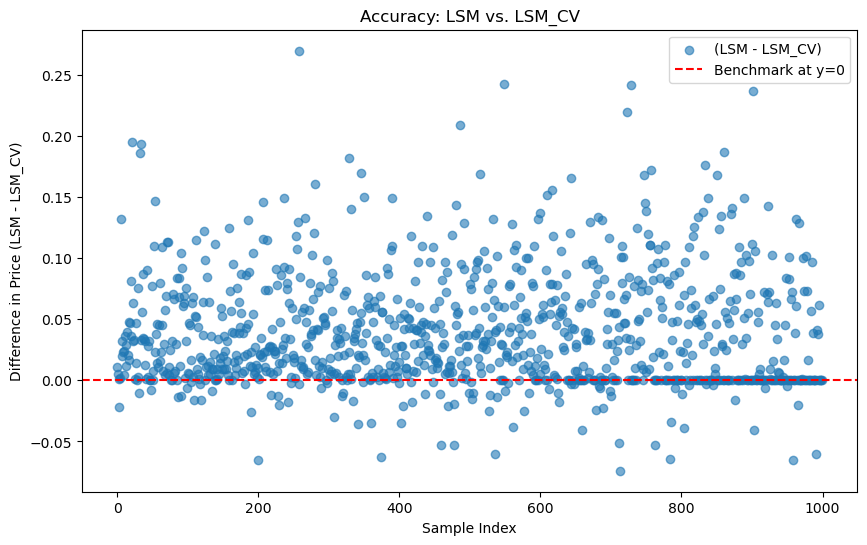

In [242]:
# Scatterplot to see if there is an accuracy change of LSM with Control Variate compared to LSM without CV
plt.figure(figsize=(10, 6))
plt.scatter(range(len(cv_comparison_df)),
            cv_comparison_df['Difference in Price'],
            alpha=0.6, label='(LSM - LSM_CV)')
plt.axhline(y=0, color='red', linestyle='--', label='Benchmark at y=0')
plt.xlabel('Sample Index')
plt.ylabel('Difference in Price (LSM - LSM_CV)') 
plt.title("Accuracy: LSM vs. LSM_CV")
plt.legend()
plt.show()

Text(0.5, 1.0, 'Variance Comparison between LSM with and without Control Variate')

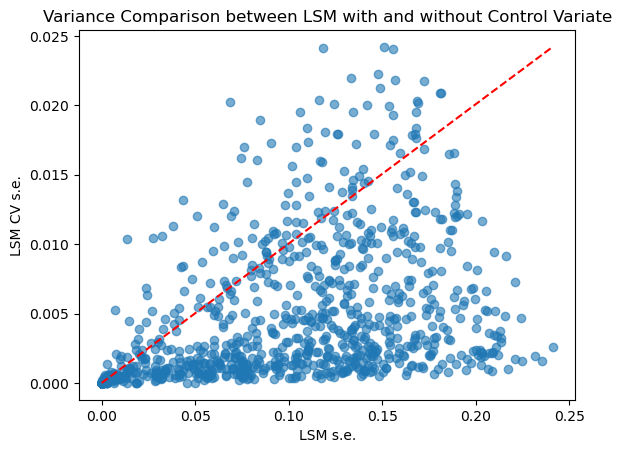

In [243]:
# Scatterplot to see if there is a variance reduction of LSM with Control Variate compared to LSM without CV
plt.scatter(cv_comparison_df['LSM s.e.'],
            cv_comparison_df['LSM CV s.e.'],
            alpha=0.6)
plt.plot([0, cv_comparison_df['LSM s.e.'].max()], [0, cv_comparison_df['LSM CV s.e.'].max()], 'r--')  # Line y=x for reference
plt.xlabel('LSM s.e.')
plt.ylabel('LSM CV s.e.')
plt.title('Variance Comparison between LSM with and without Control Variate')

# Comparison between LSM & LSM_LOO: Look-Ahead Bias Removal while no extra cost (Variance Similar)

In [ ]:
# (Part 6) LSM with Leave-One-Out Cross Validation
    #Compare price and early exercise premium under LSM with and without LOOCV - Accuracy Comparison and Variance Comparison
def LOO_compare(LSM_engine, LSM_LOO_engine, option_type = 'put', n_samples = 200, iterations = 25, seed = 42):
    """
    Here we run random parameter sampling benchmark on our LSM engine
        Compare LSM with Control Variate versus LSM without CV across all randomly generated parameters (with K fixed at 100)
    Input:
        LSM_engine: our own implementation of LSM
            LSM(S0, K, T, r, q, sigma, n_steps, n_paths, option_type='put')
        LSM_LOO_engine: implementation of LSM algorithm with Leave-Out-One Cross-Validation Method
            LSM_LOO(S0, K, T, r, q, sigma, n_steps, n_paths, degree, option_type='put', use_loo = True)
        iterations: as it states, the iteration times to reduce randomness
        parameters: S0, K, T, r, q, sigma, (n_steps, n_paths)
    Return:
        dataframe: a DataFrame compare the price, early exercise premium, variance, etc. between LSM with and without LOO Cross-Validation
    """
    # Parameters
    np.random.seed(seed)
    strike = 100 # We fix K at 100 for convenience (ITM, ATM, OTM)
    stock = np.random.uniform(60, 140, n_samples) # from deep ITM to deep OTM
    volatility = np.random.uniform(0.050, 0.60, n_samples)
    duration = np.random.uniform(0.25, 3.0, n_samples)
    interest = np.random.uniform(0.01, 0.15, n_samples)
    dividend = np.random.uniform(0.00, 0.08, n_samples)

    results = []

    for indx in range(n_samples):
        n_steps = int(50 * duration[indx])
        S0 = round(stock[indx], 3)
        K = strike
        sigma = round(volatility[indx], 4)
        T = round(duration[indx], 4)
        r = round(interest[indx], 4)
        q = round(dividend[indx], 4)

        # LSM without LOO-Cross-Validation Iterations
        lsm_prices = []
        lsm_std = []
        for i in range(iterations):
            np.random.seed(seed*100 + indx*10 + i)
            price, std = LSM_engine(
                S0 = S0, K = K, T = T, r = r, q = q, option_type = option_type,
                sigma = sigma, degree = 3, n_steps = n_steps, n_paths = 15000)
            lsm_prices.append(price)
            lsm_std.append(std)
        lsm_price = np.mean(lsm_prices)
        lsm_se = np.mean(lsm_std)

        # LSM with LOO 
        lsm_loo_prices = []
        lsm_loo_std = []
        for k in range(iterations):
            np.random.seed(seed*100 + indx*10 + k + 100)
            price_loo, std_loo = LSM_LOO_engine(
                S0, K, T, r, q, sigma, n_steps, n_paths=15000, degree=3, option_type='put', use_loo = True
            )
            lsm_loo_prices.append(price_loo)
            lsm_loo_std.append(std_loo)
        lsm_loo_price = np.mean(lsm_loo_prices)
        lsm_loo_se = np.mean(lsm_loo_std)

        # BSM on European Options
        bsm_price, _ = BSM(S0, K, T, r, q, sigma, option_type = option_type)

        moneyness = round(S0 / K , 3)

        results.append({
            "T": T,
            "Moneyness": round(moneyness, 3),
            "LSM price": round(lsm_price, 3),
            "LSM s.e.": round(lsm_se, 6),
            "LSM Early Exercise Premium": round(lsm_price - bsm_price, 4),
            "LSM LOO price": round(lsm_loo_price, 3),
            "LSM LOO s.e.": round(lsm_loo_se, 6),
            "LSM LOO Early Exercise Premium": round(lsm_loo_price - bsm_price, 4),
            "Difference in Price": round(lsm_price - lsm_loo_price, 3),
            "Difference in Early Exercise Premium": round((lsm_price - bsm_price) - (lsm_loo_price - bsm_price), 4),
            "Variance Reduction (%)": round((lsm_se**2 - lsm_loo_se**2) / (lsm_se**2 + 1e-6) * 100, 2),
            "Whether LSM LOO has variance reduction": "yes" if (lsm_loo_se**2) < (lsm_se**2) else "no"
        })

        if (indx + 1) % 100 == 0:
            print(f" {indx+1} / {n_samples} done...")

    results = pd.DataFrame(results)
    if option_type == 'put':
        results['Moneyness_Bucket'] = pd.cut(results['Moneyness'], 
                                             bins=[0, 0.9, 1.1, 2.0], 
                                            labels=['ITM (Put)', 'ATM', 'OTM (Put)'])
    else:
        results['Moneyness_Bucket'] = pd.cut(results['Moneyness'], 
                                             bins=[0, 0.9, 1.1, 2.0], 
                                            labels=['OTM (Call)', 'ATM', 'ITM (Call)'])
    return results.sort_values(by=['Moneyness', 'T'], ascending=[False, False])
        
# Table Return
if __name__ == "__main__":
    import time

    start = time.time()
    loo_comparison_df = LOO_compare(LSM, LSM_LOO, option_type = 'put', n_samples = 1000, iterations = 10, seed = 42)
    elapsed = time.time() - start

    print(f"\n Total Cases: {len(loo_comparison_df)}")
    print(f"Runtime: {elapsed:.1f}s")
    print(f"Mean |Difference in Price|: {loo_comparison_df['Difference in Price'].abs().mean():.4f}")
    print(f"Max |Difference in Price|: {loo_comparison_df['Difference in Price'].abs().max():.4f}")
    print(f"Mean |Difference in Early Exercise|: {loo_comparison_df['Difference in Early Exercise Premium'].abs().mean():.4f}")
    print(f"Max |Difference in Early Exercise|: {loo_comparison_df['Difference in Early Exercise Premium'].abs().max():.4f}")
    variance_reduc = (loo_comparison_df['Whether LSM LOO has variance reduction'] == 'yes').sum() / len(loo_comparison_df)
    print(f"Cases with Variance Reduction: {variance_reduc:.2%}")
    loo_comparison_df.to_csv("LOO_comparison.csv", index = False)

    loo_summary = loo_comparison_df.groupby('Moneyness_Bucket', observed=False).agg({
        "Difference in Price": ['mean', 'std'],
        "Difference in Early Exercise Premium": ['mean', 'std'],
        "Whether LSM LOO has variance reduction": lambda x: (x == 'yes').mean()/len(cv_comparison_df)
    })
    loo_summary 

 20 / 1000 done...
 40 / 1000 done...
 60 / 1000 done...
 80 / 1000 done...
 100 / 1000 done...
 120 / 1000 done...
 140 / 1000 done...
 160 / 1000 done...
 180 / 1000 done...
 200 / 1000 done...
 220 / 1000 done...
 240 / 1000 done...
 260 / 1000 done...
 280 / 1000 done...
 300 / 1000 done...
 320 / 1000 done...
 340 / 1000 done...
 360 / 1000 done...
 380 / 1000 done...
 400 / 1000 done...
 420 / 1000 done...
 440 / 1000 done...
 460 / 1000 done...
 480 / 1000 done...
 500 / 1000 done...
 520 / 1000 done...
 540 / 1000 done...
 560 / 1000 done...
 580 / 1000 done...
 600 / 1000 done...
 620 / 1000 done...
 640 / 1000 done...
 660 / 1000 done...
 680 / 1000 done...
 700 / 1000 done...
 720 / 1000 done...
 740 / 1000 done...
 760 / 1000 done...
 780 / 1000 done...
 800 / 1000 done...
 820 / 1000 done...
 840 / 1000 done...
 860 / 1000 done...
 880 / 1000 done...
 900 / 1000 done...
 920 / 1000 done...
 940 / 1000 done...
 960 / 1000 done...
 980 / 1000 done...
 1000 / 1000 done...

 T

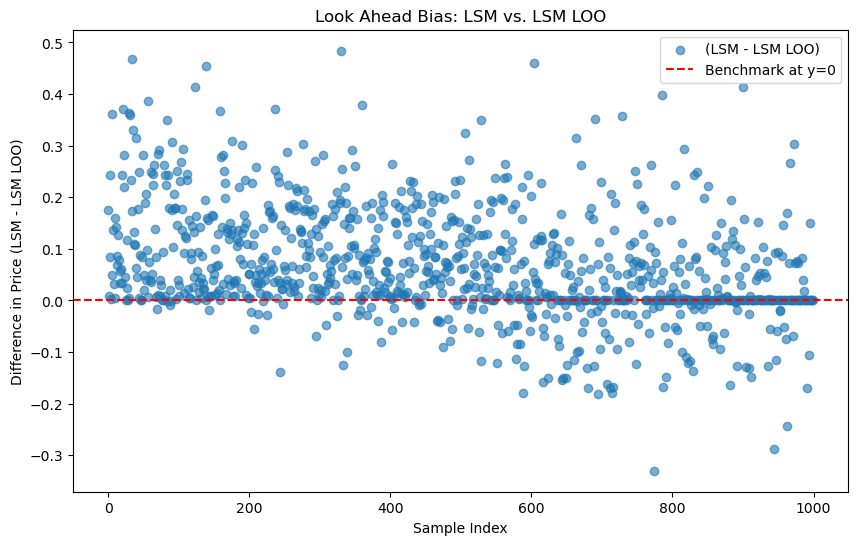

In [244]:
# Scatterplot to see if the problem of Look-Ahead Bias is removed by using LOO Cross-Validation Method in LSM
b = 0.0 # benchmark line at y=1 for accuracy comparison
plt.figure(figsize=(10, 6))
plt.scatter(range(len(loo_comparison_df)),
            loo_comparison_df['Difference in Price'],
            alpha=0.6, label='(LSM - LSM LOO)')
plt.axhline(y=0, color='red', linestyle='--', label='Benchmark at y=0')
plt.xlabel('Sample Index')
plt.ylabel('Difference in Price (LSM - LSM LOO)') 
plt.title("Look Ahead Bias: LSM vs. LSM LOO")
plt.legend()
plt.show()

Text(0.5, 1.0, 'Variance Comparison between LSM with and without LOO Cross Validation')

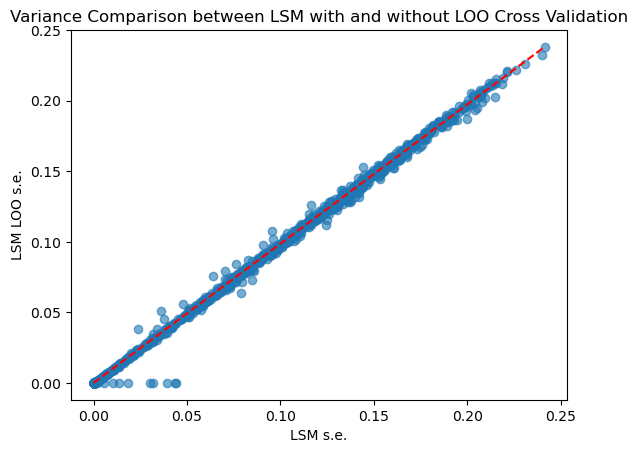

In [245]:
# Scatterplot to see if there is a variance reduction of LSM with Control Variate compared to LSM without CV
plt.scatter(loo_comparison_df['LSM s.e.'],
            loo_comparison_df['LSM LOO s.e.'],
            alpha=0.6)
plt.plot([0, loo_comparison_df['LSM s.e.'].max()], [0, loo_comparison_df['LSM LOO s.e.'].max()], 'r--')  # Line y=x for reference
plt.xlabel('LSM s.e.')
plt.ylabel('LSM LOO s.e.')
plt.title('Variance Comparison between LSM with and without LOO Cross Validation')

# Accuracy Comparison among LSM, LSM_CV, LSM_LOO for Pricing Accuracy (FDM)

In [141]:
# (Part 7) Accuracy Comparison among LSM with neither, LSM with CV, LSM with LOO, and LSM with both CV and LOO
def accuracy_compare(LSM_engine, LSM_CV_engine, LSM_LOO_engine, LSM_LOO_CV_engine, FDM_engine, option_type = 'put', n_samples = 200, iterations = 25, seed = 42):
    """
    Here we run random parameter sampling benchmark on our LSM engine
        Compare LSM with Control Variate versus LSM without CV across all randomly generated parameters (with K fixed at 100)
    Input:
        LSM_engine: our own implementation of LSM 
            LSM(S0, K, T, r, q, sigma, n_steps, n_paths, option_type='put')
        LSM_CV_engine: implementation of LSM algorithm with Control Variate
            LSM_CV(S0, K, T, r, q, sigma, n_steps, n_paths, degree, option_type='put', control_type = 'european_at_maturity')
        LSM_LOO_engine: implementation of LSM algorithm with Leave-Out-One Cross-Validation Method
            LSM_LOO(S0, K, T, r, q, sigma, n_steps, n_paths, degree, option_type='put', use_loo = True)
        LSM_LOO_CV_engine: implementation of LSM algorithm with Leave-Out-One Cross-Validation Method and Control Variate
            LSM_LOO(S0, K, T, r, q, sigma, n_steps, n_paths, degree, option_type='put', control_type = 'european_at_maturity', use_loo = True)
        FDM_engine: implementation of FDM engine for American Option Pricing
            FDM(S0, K, T, r, q, sigma, option_type = 'put')
        iterations: as it states, the iteration times to reduce randomness
        parameters: S0, K, T, r, q, sigma, (n_steps, n_paths)
    Return:
        dataframe: a DataFrame compare the price accuracy, variance, etc. among four models with benchmark of FDM engine
    """
    # Parameters
    np.random.seed(seed)
    strike = 100 # We fix K at 100 for convenience (ITM, ATM, OTM)
    stock = np.random.uniform(60, 140, n_samples) # from deep ITM to deep OTM
    volatility = np.random.uniform(0.050, 0.60, n_samples)
    duration = np.random.uniform(0.25, 3.0, n_samples)
    interest = np.random.uniform(0.01, 0.15, n_samples)
    dividend = np.random.uniform(0.00, 0.08, n_samples)

    results = []

    for indx in range(n_samples):
        n_steps = int(50 * duration[indx])
        S0 = round(stock[indx], 3)
        K = strike
        sigma = round(volatility[indx], 4)
        T = round(duration[indx], 4)
        r = round(interest[indx], 4)
        q = round(dividend[indx], 4)

        lsm_prices = []
        lsm_std = []
        lsm_cv_prices = []
        lsm_cv_std = []
        lsm_loo_prices = []
        lsm_loo_std = []
        lsm_loo_cv_prices = []
        lsm_loo_cv_std = []

        for i in range(iterations):
            np.random.seed(seed*100 + indx*10 + i)
        
        # LSM without Control Variate Iterations
            price, std = LSM_engine(
                S0 = S0, K = K, T = T, r = r, q = q, option_type = option_type,
                sigma = sigma, degree = 3, n_steps = n_steps, n_paths = 15000)
            lsm_prices.append(price)
            lsm_std.append(std)

        # LSM with Control Variate Iterations - CV: European Option at exercise
            price_cv, std_cv = LSM_CV_engine(
                S0, K, T, r, q, sigma, n_steps, n_paths=15000, degree=3, option_type='put', control_type = 'european_at_exercise'
            )
            lsm_cv_prices.append(price_cv)
            lsm_cv_std.append(std_cv)

        # LSM with LOO 
        for k in range(iterations):
            np.random.seed(seed*100 + indx*10 + k + 100)
            price_loo, std_loo = LSM_LOO_engine(
                S0, K, T, r, q, sigma, n_steps, n_paths=15000, degree=3, option_type='put', use_loo = True
            )
            lsm_loo_prices.append(price_loo)
            lsm_loo_std.append(std_loo)

        # LSM with Control Variate and LOO Cross Validation

        for m in range(iterations):
            np.random.seed(seed*100 + indx*10 + m + 2000)
            price_loo_cv, std_loo_cv = LSM_LOO_CV_engine(
                S0, K, T, r, q, sigma, 
                n_steps, n_paths=15000, degree=3, option_type='put', 
                use_loo = True, control_type = 'european_at_exercise'
            )
            lsm_loo_cv_prices.append(price_loo_cv)
            lsm_loo_cv_std.append(std_loo_cv)
        
        lsm_price = np.mean(lsm_prices)
        lsm_se = np.mean(lsm_std)
        lsm_cv_price = np.mean(lsm_cv_prices)
        lsm_cv_se = np.mean(lsm_cv_std)
        lsm_loo_price = np.mean(lsm_loo_prices)
        lsm_loo_se = np.mean(lsm_loo_std)
        lsm_loo_cv_price = np.mean(lsm_loo_cv_prices)
        lsm_loo_cv_se = np.mean(lsm_loo_cv_std)


        # FDM engine iterations 
        fdm_price, _ = FDM_engine(S0 = S0, K = K, T = T, r = r, q = q, option_type = option_type, sigma = sigma)


        # BSM on European Options
        bsm_price, _ = BSM(S0, K, T, r, q, sigma, option_type = option_type)


        moneyness = round(S0 / K , 3)

        results.append({
            "T": T,
            "Moneyness": round(moneyness, 3),
            "LSM price": round(lsm_price, 3),
            "LSM s.e.": round(lsm_se, 6),
            "LSM CV price": round(lsm_cv_price, 3),
            "LSM CV s.e.": round(lsm_cv_se, 6),
            "LSM LOO price": round(lsm_loo_price, 3),
            "LSM LOO s.e.": round(lsm_loo_se, 6),
            "LSM LOO CV price": round(lsm_loo_cv_price, 3),
            "LSM LOO CV s.e.": round(lsm_loo_cv_se, 6),
            "Accuracy (LSM vs. FDM)": round(lsm_price - fdm_price, 3),
            "Accuracy (LSM CV vs. FDM)": round(lsm_cv_price - fdm_price, 3),
            "Accuracy (LSM LOO vs. FDM)": round(lsm_loo_price - fdm_price, 3),
            "Accuracy (LSM LOO CV vs. FDM)": round(lsm_loo_cv_price - fdm_price, 3)
        })

        if (indx + 1) % 50 == 0:
            print(f" {indx+1} / {n_samples} done...")

    results = pd.DataFrame(results)
    if option_type == 'put':
        results['Moneyness_Bucket'] = pd.cut(results['Moneyness'], 
                                             bins=[0, 0.9, 1.1, 2.0], 
                                            labels=['ITM (Put)', 'ATM', 'OTM (Put)'])
    else:
        results['Moneyness_Bucket'] = pd.cut(results['Moneyness'], 
                                             bins=[0, 0.9, 1.1, 2.0], 
                                            labels=['OTM (Call)', 'ATM', 'ITM (Call)'])
    return results.sort_values(by=['Moneyness', 'T'], ascending=[False, False])
        
# Table Return
if __name__ == "__main__":
    import time

    start = time.time()
    accuracy_df = accuracy_compare(LSM, LSM_CV, LSM_LOO, LOOLSM_CV, FDM, option_type = 'put', n_samples = 500, iterations = 10, seed = 42)
    elapsed = time.time() - start

    accuracy_df.to_csv("accuracy_comparison.csv", index = False)

 50 / 500 done...
 100 / 500 done...
 150 / 500 done...
 200 / 500 done...
 250 / 500 done...
 300 / 500 done...
 350 / 500 done...
 400 / 500 done...
 450 / 500 done...
 500 / 500 done...


In [142]:
four_model= accuracy_df.groupby('Moneyness_Bucket', observed=False).agg({
    "Accuracy (LSM vs. FDM)": ['mean', 'std'],
    "Accuracy (LSM CV vs. FDM)": ['mean', 'std'],
    "Accuracy (LSM LOO vs. FDM)": ['mean', 'std'],
    "Accuracy (LSM LOO CV vs. FDM)": ['mean', 'std']
})

four_model

Accuracy (LSM vs. FDM)           Accuracy (LSM CV vs. FDM)  \
                                   mean       std                      mean   
Moneyness_Bucket                                                              
ITM (Put)                      0.009495  0.038752                 -0.023232   
ATM                            0.016570  0.037859                 -0.026364   
OTM (Put)                      0.018877  0.034479                 -0.020174   

                           Accuracy (LSM LOO vs. FDM)            \
                       std                       mean       std   
Moneyness_Bucket                                                  
ITM (Put)         0.026891                  -0.013869  0.101002   
ATM               0.027408                  -0.048393  0.115110   
OTM (Put)         0.029644                  -0.087774  0.089856   

                 Accuracy (LSM LOO CV vs. FDM)            
                                          mean       std  
Moneyness_Bucket                                          
ITM (Put)                            -0.026631  0.032593  
ATM                                  -0.032374  0.033933  
OTM (Put)                            -0.026928  0.035531

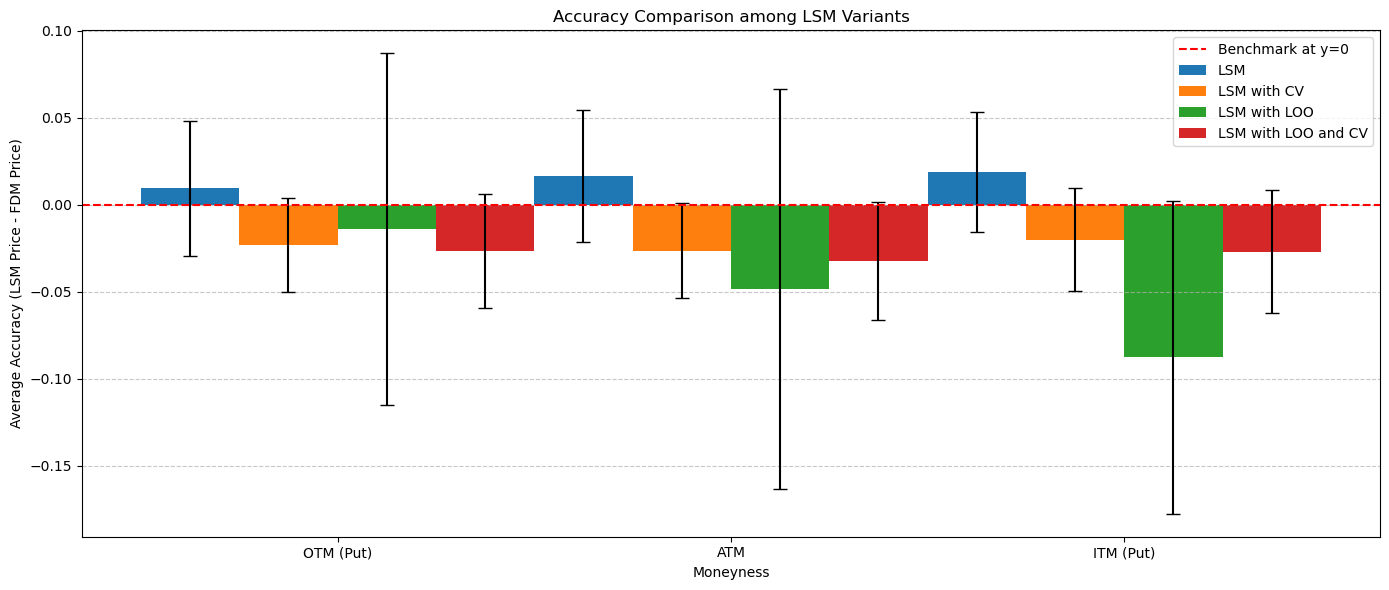

In [246]:
# Box Plot to visualize the accuracy distribution among four LSM variants across different moneyness buckets
categories = accuracy_df['Moneyness_Bucket'].unique()
lsm = accuracy_df.groupby('Moneyness_Bucket')['Accuracy (LSM vs. FDM)'].mean()
lsm_cv = accuracy_df.groupby('Moneyness_Bucket')['Accuracy (LSM CV vs. FDM)'].mean()
lsm_loo = accuracy_df.groupby('Moneyness_Bucket')['Accuracy (LSM LOO vs. FDM)'].mean()
lsm_loo_cv = accuracy_df.groupby('Moneyness_Bucket')['Accuracy (LSM LOO CV vs. FDM)'].mean()

lsm_sd = accuracy_df.groupby('Moneyness_Bucket')['Accuracy (LSM vs. FDM)'].std()
lsm_cv_sd = accuracy_df.groupby('Moneyness_Bucket')['Accuracy (LSM CV vs. FDM)'].std()
lsm_loo_sd = accuracy_df.groupby('Moneyness_Bucket')['Accuracy (LSM LOO vs. FDM)'].std()
lsm_loo_cv_sd = accuracy_df.groupby('Moneyness_Bucket')['Accuracy (LSM LOO CV vs. FDM)'].std()

x = np.arange(len(categories)) # label location along x-aix
w = 0.25 # bar width

fig, axes = plt.subplots(figsize=(14, 6))

axes.bar(x - 1.5*w, lsm, width=w, yerr =lsm_sd, label='LSM', capsize = 5)
axes.bar(x - 0.5*w, lsm_cv, width=w, yerr =lsm_cv_sd, label='LSM with CV', capsize = 5)
axes.bar(x + 0.5*w, lsm_loo, width=w, yerr =lsm_loo_sd, label='LSM with LOO', capsize = 5)
axes.bar(x + 1.5*w, lsm_loo_cv, width=w, yerr =lsm_loo_cv_sd, label='LSM with LOO and CV', capsize = 5)

axes.axhline(y=0, color='red', linestyle='--', label='Benchmark at y=0')
axes.set_xticks(x)
axes.set_xticklabels(categories)
axes.set_xlabel('Moneyness')
axes.set_ylabel('Average Accuracy (LSM Price - FDM Price)')
axes.set_title('Accuracy Comparison among LSM Variants')
axes.legend()
axes.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# SPEED: Our LSM vs. Luphord's LSM
Baseline: https://github.com/luphord/longstaff_schwartz

- Performance Trade-Off: Our engine adds ~28 milliseconds of overhead per run to support multi-asset pricing, control variates, and leave-one-out bias correction. The baseline implementation is strictly for single-asset problems.
- Superior Stability: Our engine reliably prices extreme out-of-the-money (OTM) options where the baseline model crashes.

In [ ]:
pip install longstaff-schwartz

In [136]:
# Install Luphord's LSM Implementation
from LSM.regression_bases import PowerPolynomials
from longstaff_schwartz.algorithm import longstaff_schwartz
from longstaff_schwartz.stochastic_process import GeometricBrownianMotion as LGBM

# Luphord's LSM Implementation
def Luphord_LSM(S0, K, T, r, q, sigma, n_steps, n_paths, option_type='put'):
    """
    Installation and Internalization of Luphord's Implementtaion of LSM Engine
    Input:
        Necessary Parameters for LSM Engine: S0, K, T, r, q, sigma, n_steps, n_paths, option_type
    Return:
        Option Price estimated by Luphord's LSM implementation
    """
    t = np.linspace(0, T, n_steps + 1)
    sigma = sigma
    n = n_paths

    lgbm = LGBM(mu=r-q, sigma=sigma)
    rnd = np.random.RandomState()
    x = lgbm.simulate(t, n, rnd) * S0

    strike = K

    def put_payoff(spot):
        return np.maximum(strike - spot, 0.0)
    
    def constant_rate_df(t_from, t_to):
        return np.exp(-r * (t_to - t_from))
    
    def fit_quadratic(x, y):
        return np.polynomial.Polynomial.fit(x, y, 3, rcond=None)
    
    def itm(payoff, spot):
        return payoff > 0 
    
    npv_american = longstaff_schwartz(x, t, constant_rate_df, fit_quadratic, put_payoff, itm)
    npv_european = constant_rate_df(t[0], t[-1]) * put_payoff(x[-1]).mean()

    return npv_american
    

In [145]:
# Sample test parameters from Paper
S0 = 36
K = 40
r = 0.06
q = 0.0
sigma = 0.2
T = 1.0
n_steps = 50
n_paths = 10000

# American Put option price by our LSM
start_lsm = time.time()
lsm_put, std = LSM(S0 = S0, K = K, T = T, r = r, q = q, option_type = 'put',
                sigma = sigma, degree = 3, n_steps = n_steps, n_paths=n_paths)
end_lsm = time.time()
print(f"LSM American Put Price {lsm_put}.")

# American Put option price by Luphord's LSM
start_luphord = time.time()
luphord_put = Luphord_LSM(S0, K, T, r, q, sigma, n_steps, n_paths, option_type='put')
end_luphord = time.time()
print(f"Luphord's LSM American Put Price {luphord_put}.")

print(f"LSM Runtime: {end_lsm - start_lsm}")
print(f"Luphord's LSM Runtime: {end_luphord - start_luphord}")

LSM American Put Price 4.472038706158595.
Luphord's LSM American Put Price 4.461847459318207.
LSM Runtime: 0.06611371040344238
Luphord's LSM Runtime: 0.050373077392578125


In [230]:
#(Part 8) Comparison of Accuracy and Runtime between Our LSM Implementation and Luphord's LSM Implementation
import os
import sys
import time
import warnings
import numpy as np
import pandas as pd
from LSM.regression_bases import PowerPolynomials
from longstaff_schwartz.algorithm import longstaff_schwartz
from longstaff_schwartz.stochastic_process import GeometricBrownianMotion as LGBM

os.environ["OPENBLAS_VERBOSE"] = "0"
warnings.filterwarnings("ignore")


# ── LAPACK stderr suppression (Jupyter-safe) ──────────────────────────────────
# LAPACK writes directly to C-level fd=2, bypassing sys.stderr.
# We redirect both so it works in scripts AND notebooks.
class _SuppressAllStderr:
    def __enter__(self):
        self._devnull   = open(os.devnull, "w")
        self._old_fd    = os.dup(2)
        self._old_py    = sys.stderr
        os.dup2(self._devnull.fileno(), 2)
        sys.stderr      = self._devnull
        return self

    def __exit__(self, *_):
        os.dup2(self._old_fd, 2)
        os.close(self._old_fd)
        sys.stderr = self._old_py
        self._devnull.close()


# ── Luphord ITM guard (wrapper only, algorithm unchanged) ────────────────────
# Luphord's fit_quadratic crashes on empty arrays (deep OTM).
# We wrap it to return a zero-function instead — same numerical result,
# no LAPACK error.
def _safe_luphord(S0, K, T, r, q, sigma, n_steps, n_paths, option_type="put", seed=None):
    strike = K
    if option_type == "put":
        def payoff(s): return np.maximum(strike - s, 0.0)
    else:
        def payoff(s): return np.maximum(s - strike, 0.0)

    def df(t0, t1):    return np.exp(-r * (t1 - t0))
    def itm(ex, spot): return ex > 0

    def safe_fit(x_itm, y_itm):
        if len(x_itm) == 0:
            return lambda x: np.zeros_like(x)
        return np.polynomial.Polynomial.fit(x_itm, y_itm, 3, rcond=None)

    def luphord_fn():                                      # simulate 在计时内
        t   = np.linspace(0, T, n_steps + 1)
        rnd = np.random.RandomState(seed)                  # 固定 seed
        x   = LGBM(mu=r - q, sigma=sigma).simulate(t, n_paths, rnd) * S0
        return longstaff_schwartz(x, t, df, safe_fit, payoff, itm)

    return luphord_fn


def LSM_comparable(S0, K, T, r, q, sigma, n_steps, n_paths, option_type="put"):
    from LSM.stochastic_processes import GeometricBrownianMotion
    from LSM.payoffs import VanillaPayoff
    from LSM.regression_bases import PowerPolynomials
    
    process = GeometricBrownianMotion(
        S0=np.array([S0]), r=r, q=np.array([q]), sigma=np.array([sigma])
    )
    payoff  = VanillaPayoff(strike=K, option_type=option_type)
    basis   = PowerPolynomials(degree=3)
    
    return LeastSquaresMonteCarlo(process=process, payoff_function=payoff, basis_function=basis)

# ── main comparison ───────────────────────────────────────────────────────────
def compare_runtime(
    our_engine,
    option_type : str = "put",
    n_cases     : int = 100,
    n_paths     : int = 15000,
    seed        : int = 42,
    use_degree  : bool = True,   # False when our_engine already has basis baked in
):
    """
    Fair wall-clock comparison: our LSM vs luphord's LSM.

    Both engines
      - receive identical parameters including n_paths
      - are seeded identically so paths are comparable
      - are timed with time.perf_counter() around a single call
      - have LAPACK stderr suppressed at the OS level

    Failed cases are skipped (not recorded as 0s).
    Runtime difference is reported in absolute seconds.
    """
    np.random.seed(seed)

    S0s    = np.random.uniform(60,   95,  n_cases)
    Ts     = np.random.uniform(0.25,  3.0, n_cases)
    rs     = np.random.uniform(0.01, 0.15, n_cases)
    qs     = np.random.uniform(0.00, 0.08, n_cases)
    sigmas = np.random.uniform(0.05, 0.60, n_cases)

    rows = []

    for i in range(n_cases):
        S0      = round(float(S0s[i]),    3)
        K       = 100
        T       = round(float(Ts[i]),     4)
        r       = round(float(rs[i]),     4)
        q       = round(float(qs[i]),     4)
        sigma   = round(float(sigmas[i]), 4)
        n_steps = max(1, int(50 * T))

        row = dict(
            S0=S0, K=K, T=T, r=r, q=q, sigma=sigma,
            n_steps=n_steps, n_paths=n_paths,
            Moneyness=round(S0 / K, 3),
            our_price=np.nan, our_time=np.nan, our_ok=False,
            lup_price=np.nan, lup_time=np.nan, lup_ok=False,
        )

        case_seed = seed * 1000 + i

        # ── our engine ────────────────────────────────────────────────────────
        np.random.seed(case_seed)
        with _SuppressAllStderr():
            try:
                kw = dict(S0=S0, K=K, T=T, r=r, q=q, sigma=sigma,
                          n_steps=n_steps, n_paths=n_paths,
                          option_type=option_type)
                if use_degree:
                    kw["degree"] = 3
                engine = our_engine(**kw)
                rng = np.random.default_rng(case_seed)
                t0 = time.perf_counter()
                result = engine.pricer(T=T, n_steps=n_steps, n_paths=n_paths, rng=rng)
                row["our_time"]  = time.perf_counter() - t0
                row["our_price"] = float(result[0])
                row["our_ok"]    = True
            except Exception:
                pass

        # ── luphord engine ────────────────────────────────────────────────────
        np.random.seed(case_seed)
        with _SuppressAllStderr():
            try:
                luphord_fn = _safe_luphord(S0, K, T, r, q, sigma, n_steps, n_paths, option_type, seed = case_seed)
                t0 = time.perf_counter()
                row["lup_price"] = float(luphord_fn())
                row["lup_time"]  = time.perf_counter() - t0
                row["lup_ok"]    = True
            except Exception:
                pass

        rows.append(row)

    df = pd.DataFrame(rows)

    labels = (["ITM (Put)", "ATM", "OTM (Put)"] if option_type == "put"
              else ["OTM (Call)", "ATM", "ITM (Call)"])
    df["Moneyness_Bucket"] = pd.cut(
        df["Moneyness"], bins=[0, 0.9, 1.1, 2.0], labels=labels)

    both = df["our_ok"] & df["lup_ok"]
    df.loc[both, "Runtime_Diff_s"] = df.loc[both, "our_time"] - df.loc[both, "lup_time"]
    df.loc[both, "Price_Diff"]     = df.loc[both, "our_price"] - df.loc[both, "lup_price"]

    valid = df[both].copy()
    n_ok  = both.sum()

    print(f"\n{'='*62}")
    print(f"  n_paths={n_paths}  cases={n_cases}  both_ok={n_ok}  failed={n_cases - n_ok}")
    print(f"{'='*62}")
    print(f"  Our LSM  — mean {valid['our_time'].mean():.4f}s  std {valid['our_time'].std():.4f}s")
    print(f"  Luphord  — mean {valid['lup_time'].mean():.4f}s  std {valid['lup_time'].std():.4f}s")
    diff = valid["Runtime_Diff_s"].mean()
    print(f"  Diff     — mean {diff:+.4f}s  ({'ours faster' if diff < 0 else 'luphord faster'})")
    print(f"{'='*62}\n")

    summary = (
        valid.groupby("Moneyness_Bucket", observed=False)
        .agg(
            our_mean_s  =("our_time",       "mean"),
            lup_mean_s  =("lup_time",       "mean"),
            diff_mean_s =("Runtime_Diff_s", "mean"),
            price_diff  =("Price_Diff",     "mean"),
            n           =("our_time",       "count"),
        )
        .round(5)
    )
    print(summary)
    return df, summary


# ── usage ─────────────────────────────────────────────────────────────────────
#
# Laguerre basis (default):
#   df, summary = compare_runtime(our_engine=LSM, use_degree=True)
#
# Power / comparable basis (no degree arg):
#   df, summary = compare_runtime(our_engine=LSM_comparable, use_degree=False)
df, summary = compare_runtime(
    our_engine=LSM_comparable, 
    use_degree=False,
    n_cases = 100,
    n_paths = 15000,
    seed = 42,)

print("\n--- ITM-focused benchmark (S0 in [60, 95], all puts ITM) ---")

print("=== Full Range ===")
df_full, summary_full = compare_runtime(
    our_engine=LSM_comparable, 
    use_degree=False)
print("Note that S0s backup here = (60, 140) so some cases are ATM/OTM.")

 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value

  n_paths=15000  cases=100  both_ok=92  failed=8
  Our LSM  — mean 0.1513s  std 0.1150s
  Luphord  — mean 0.1231s  std 0.0892s
  Diff     — mean +0.0282s  (luphord faster)

         S0       T  n_steps  our_time  lup_time
1   136.057  2.0001      100  0.287102  0.144250
4    72.481  2.7458      137  0.255071  0.581533
5    72.480  0.9356       46  0.292379  0.084710
40   69.763  2.8967      144  0.259594  0.234505
72   60.442  1.6583       82  0.386979  0.270733
75  118.321  0.7295 

# Accuracy Convergence Test

In [247]:
# (Part 9) Convergence Grid Test to see how American Put price converges to FDM price as we increase the number of paths under different LSM variants
def convergence_test(LSM_engine, LSM_CV_engine, LOOLSM_engine, LOOLSM_CV_engine, FDM_engine, option_type = 'put', iterations = 25, seed = 42):
    """
    Here we do the Convergence Grid Test to see how American Put price converges to FDM price as we increase the number of paths under different LSM variants
    Inputs:
        LSM_engine: our own implementation of LSM 
            LSM(S0, K, T, r, q, sigma, degree, n_steps, n_paths, option_type='put')
        LSM_CV_engine: implementation of LSM algorithm with Control Variate
            LSM_CV(S0, K, T, r, q, sigma, n_steps, n_paths, degree, option_type='put', control_type = 'european_at_maturity')
        LOOLSM_engine: implementation of LSM algorithm with Leave-Out-One Cross-Validation Method
            LSM_LOO(S0, K, T, r, q, sigma, n_steps, n_paths, degree, option_type='put', use_loo = True)
        LOOLSM_CV_engine: implementation of LSM algorithm with Leave-Out-One Cross-Validation Method and Control Variate
            LSM_LOO(S0, K, T, r, q, sigma, n_steps, n_paths, degree, option_type='put', control_type = 'european_at_maturity', use_loo = True)
        FDM_engine: Finite Difference Method Engine as benchmark
            FDM(S0 = S0, K = K, T = T, r = r, q = q, sigma = sigma, option_type='put')
        iterations: as it states, the iteration times to reduce randomness
    Outputs:
        a dataframe containing the price and error convergence results under different LSM variants as we increase the number of paths, with benchmark of FDM price
    """
    # Paramters
    money = {
        'ITM (Put)': [80, 100],
        'ATM': [100, 100],
        'OTM (Put)': [120, 100]
    }
    T = 1.0
    r = 0.05
    q = 0.02
    sigma = 0.20
    n_paths = [1000, 2500, 5000, 10000, 15000, 20000]

    results = []

    for moneyness, (S0, K) in money.items():
        # FDM Evaluation
        fdm_price, _ = FDM_engine(S0 = S0, K = K, T = T, r = r, q = q, sigma = sigma)
        
        for n in n_paths:
            lsm_prices = []
            lsm_cv_prices = []
            loolsm_prices = []
            loolsm_cv_prices = []

            for i in range(iterations):
                np.random.seed(seed*100 + i)
                # LSM without CV or LOO
                price, std = LSM_engine(
                    S0, K, T, r, q, sigma, degree = 3, n_steps = 50, n_paths = n, option_type='put')
                lsm_prices.append(price)

                # LSM with CV
                price_cv, std_cv = LSM_CV_engine(
                    S0, K, T, r, q, sigma, n_steps= 50, n_paths = n, degree=3, option_type='put', control_type = 'european_at_exercise')
                lsm_cv_prices.append(price_cv)

                # LOOLSM
                price_loo, std_loo = LOOLSM_engine(
                    S0, K, T, r, q, sigma, n_steps = 50, n_paths = n, degree=3, option_type='put', use_loo = True)
                loolsm_prices.append(price_loo)

                # LOOLSM with CV
                price_loo_cv, std_loo_cv = LOOLSM_CV_engine(
                    S0, K, T, r, q, sigma, n_steps = 50, n_paths = n, degree=3, option_type='put', control_type = 'european_at_exercise', use_loo = True)
                loolsm_cv_prices.append(price_loo_cv)
            
            lsm_price = np.mean(lsm_prices)
            lsm_cv_price = np.mean(lsm_cv_prices)
            loolsm_price = np.mean(loolsm_prices)
            loolsm_cv_price = np.mean(loolsm_cv_prices)

            results.append({
                "Moneyness": moneyness,
                "Paths": n,
                "LSM Price": round(lsm_price, 4),
                "LSM CV Price": round(lsm_cv_price, 4),
                "LOOLSM Price": round(loolsm_price, 4),
                "LOOLSM CV Price": round(loolsm_cv_price, 4),
                "FDM Price": round(fdm_price, 4),
                "LSM Error (LSM - FDM)": round(lsm_price - fdm_price, 4),
                "LSM CV Error (LSM CV - FDM)": round(lsm_cv_price - fdm_price, 4),
                "LOOLSM Error (LOOLSM - FDM)": round(loolsm_price - fdm_price, 4),
                "LOOLSM CV Error (LOOLSM CV - FDM)": round(loolsm_cv_price - fdm_price, 4)
            })

    results = pd.DataFrame(results)
    results['Moneyness_Bucket'] = pd.Categorical(results['Moneyness'], categories=['ITM (Put)', 'ATM', 'OTM (Put)'], ordered=True)
    return results.sort_values(by=['Moneyness_Bucket', 'Paths'], ascending=[True, True])

if __name__ == "__main__":
    import time

    start = time.time()
    convergence_df = convergence_test(LSM, LSM_CV, LSM_LOO, LOOLSM_CV, FDM, option_type = 'put', iterations = 20, seed = 42)
    elapsed = time.time() - start

    convergence_df.to_csv("convergence_comparison.csv", index = False)

    convergence_summary = convergence_df.groupby('Moneyness_Bucket', observed=False).agg({
        "LSM Error (LSM - FDM)": ['mean', 'std'],
        "LSM CV Error (LSM CV - FDM)": ['mean', 'std'],
        "LOOLSM Error (LOOLSM - FDM)": ['mean', 'std'],
        "LOOLSM CV Error (LOOLSM CV - FDM)": ['mean', 'std']
    })
    print(convergence_summary)


                 LSM Error (LSM - FDM)           LSM CV Error (LSM CV - FDM)  \
                                  mean       std                        mean   
Moneyness_Bucket                                                               
ITM (Put)                     0.055667  0.098736                   -0.059333   
ATM                           0.034967  0.054124                   -0.033283   
OTM (Put)                     0.041283  0.046514                   -0.030817   

                           LOOLSM Error (LOOLSM - FDM)            \
                       std                        mean       std   
Moneyness_Bucket                                                   
ITM (Put)         0.020043                    0.004717  0.026137   
ATM               0.024060                    0.010967  0.061828   
OTM (Put)         0.023898                   -0.048983  0.022998   

                 LOOLSM CV Error (LOOLSM CV - FDM)            
                                              m

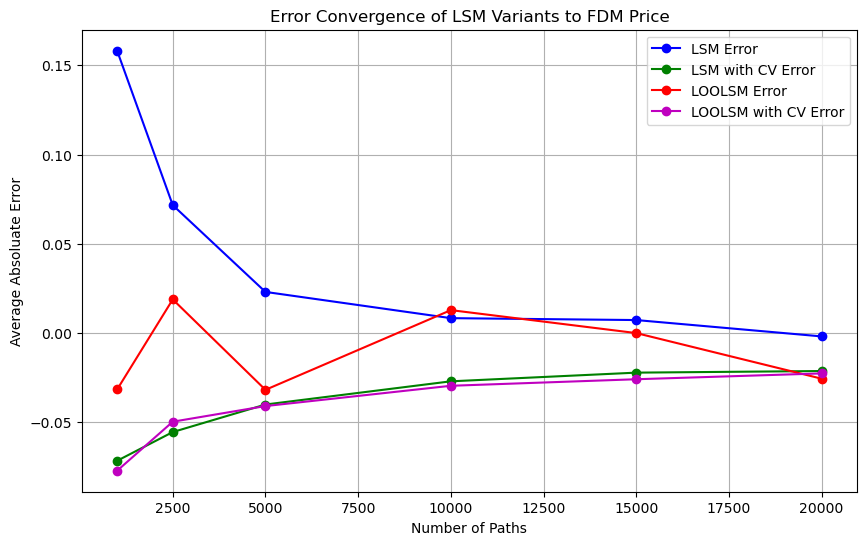

In [187]:
# Line Chart to show how error converges as we increase the number of paths under different LSM variants with regressors fixed at 4 (degree-3 polynomials)
n_arr = convergence_df['Paths'].unique()
err_lsm = convergence_df.groupby('Paths')['LSM Error (LSM - FDM)'].mean()
err_lsm_cv = convergence_df.groupby('Paths')['LSM CV Error (LSM CV - FDM)'].mean()
err_loolsm = convergence_df.groupby('Paths')['LOOLSM Error (LOOLSM - FDM)'].mean()
err_loolsm_cv = convergence_df.groupby('Paths')['LOOLSM CV Error (LOOLSM CV - FDM)'].mean()
plt.figure(figsize=(10, 6))
plt.plot(n_arr, err_lsm, 'bo-', label='LSM Error')
plt.plot(n_arr, err_lsm_cv, 'go-', label='LSM with CV Error')
plt.plot(n_arr, err_loolsm, 'ro-', label='LOOLSM Error')
plt.plot(n_arr, err_loolsm_cv, 'mo-', label='LOOLSM with CV Error')
plt.xlabel("Number of Paths")
plt.ylabel("Average Absoluate Error")
plt.title("Error Convergence of LSM Variants to FDM Price")
plt.legend()
plt.grid()


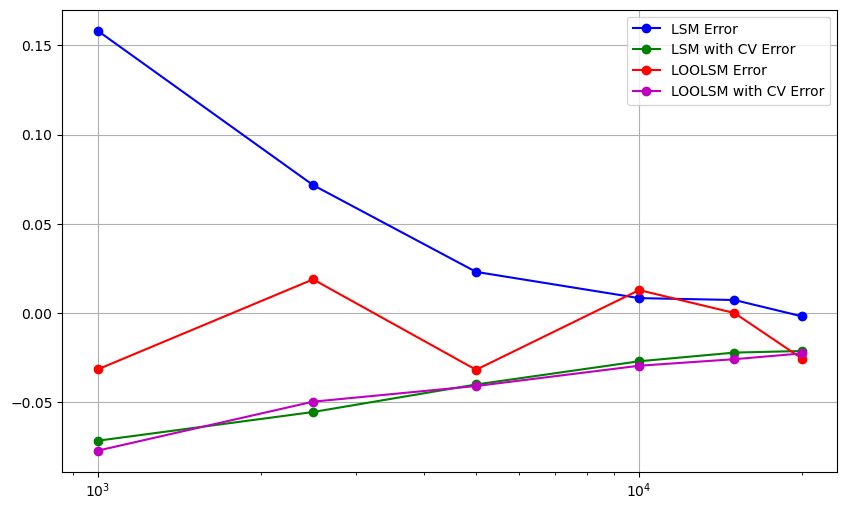

In [189]:
n_arr = convergence_df['Paths'].unique()
err_lsm = convergence_df.groupby('Paths')['LSM Error (LSM - FDM)'].mean()
err_lsm_cv = convergence_df.groupby('Paths')['LSM CV Error (LSM CV - FDM)'].mean()
err_loolsm = convergence_df.groupby('Paths')['LOOLSM Error (LOOLSM - FDM)'].mean()
err_loolsm_cv = convergence_df.groupby('Paths')['LOOLSM CV Error (LOOLSM CV - FDM)'].mean()
plt.figure(figsize=(10, 6))
plt.plot(n_arr, err_lsm, 'bo-', label='LSM Error')
plt.plot(n_arr, err_lsm_cv, 'go-', label='LSM with CV Error')
plt.plot(n_arr, err_loolsm, 'ro-', label='LOOLSM Error')
plt.plot(n_arr, err_loolsm_cv, 'mo-', label='LOOLSM with CV Error')
plt.xscale('log')
plt.legend()
plt.grid()


# Generalization
## American Call on Max of 5 Assets

In [48]:
# Longstaff & Schwartz (2001): American call on max of 5 assets (pp. 141-142)
# Parameters: 5 assets, σ=20%, div=10%, r=5%, T=3, exercise 3x/year, K=100
# Paper reports: LSM prices [16.657, 26.182, 36.812] for S0 ∈ [90, 100, 110]

print("\n" + "=" * 80)
print("Longstaff & Schwartz (2001) Benchmark: American Call on Max of 5 Assets")
print("=" * 80)

# Parameters
n_assets = 5
K = 100
r = 0.05
q = 0.10  # 10% dividend
sigma = np.array([0.20] * n_assets)  # All 20%
T = 3.0
n_steps = 9  # 3x per year × 3 years
n_paths = 50000
correlation_matrix = np.eye(n_assets)  # Independent assets

test_S0_values = [90, 100, 110]
paper_values = [16.657, 26.182, 36.812]

results = []

for S0, paper_price in zip(test_S0_values, paper_values):
    S0_vector = np.array([S0] * n_assets)
    
    # Setup
    gbm = GeometricBrownianMotion(
        S0=S0_vector, r=r, q=np.array([q] * n_assets), 
        sigma=sigma, correlation_matrix=correlation_matrix
    )
    payoff = AmericanMaxCall(strike=K)
    features = MaxCallFeatures(strike=K)
    basis = LaguerrePolynomials(degree=5)
    
    lsm_eng = LeastSquaresMonteCarlo(process=gbm, payoff_function=payoff, basis_function=basis)
    
    # Price
    lsm_price, lsm_std = lsm_eng.pricer(T=T, n_steps=n_steps, n_paths=n_paths, create_features=features, cache=False)
    
    error = lsm_price - paper_price
    
    print(f"\nS0 = {S0}:")
    print(f"  LSM Price:   {lsm_price:.3f}")
    print(f"  Paper Price: {paper_price:.3f}")
    print(f"  Error:       {error:.3f} ({error/paper_price*100:.1f}%)")
    print(f"  Std Error:   {lsm_std:.4f}")
    
    results.append({'S0': S0, 'LSM': lsm_price, 'Paper': paper_price, 'Error': error})

df_bg = pd.DataFrame(results)
print("\n" + df_bg.to_string(index=False))
print("=" * 80)


Longstaff & Schwartz (2001) Benchmark: American Call on Max of 5 Assets

S0 = 90:
  LSM Price:   16.805
  Paper Price: 16.657
  Error:       0.148 (0.9%)
  Std Error:   0.0745

S0 = 100:
  LSM Price:   26.225
  Paper Price: 26.182
  Error:       0.043 (0.2%)
  Std Error:   0.0876

S0 = 110:
  LSM Price:   36.616
  Paper Price: 36.812
  Error:       -0.196 (-0.5%)
  Std Error:   0.0987

 S0       LSM  Paper     Error
 90 16.804899 16.657  0.147899
100 26.224887 26.182  0.042887
110 36.615552 36.812 -0.196448


## Swing Option

In [56]:
# Swing Option Sanity Checks & Theoretical Properties
# Reference: Jaillet, Ronn, and Tompaidis (2004)
print("\n" + "=" * 80)
print("Swing Option Sanity Checks")
print("=" * 80)

test_steps = 50
test_paths = 10000
test_T = 1.0
test_K = 100.0
contract_prices = np.full(test_steps + 1, test_K) 

# Shared GBM process
swing_gbm = GeometricBrownianMotion(S0=100, r=0.05, q=0.0, sigma=0.2)

# Test 1: American Option Equivalency (Jaillet p. 912, Sec 2.3.1, Prop 1)
standard_eng = LeastSquaresMonteCarlo(
    process=swing_gbm,
    payoff_function=VanillaPayoff(strike=test_K, option_type="call"),
    basis_function=LaguerrePolynomials(degree=3)
)
standard_price, standard_err = standard_eng.pricer(T=test_T, n_steps=test_steps, n_paths=test_paths)

swing_eng = LeastSquaresMonteCarlo(
    process=swing_gbm,
    payoff_function=SwingSpread(option_type="call"),
    basis_function=PowerPolynomials(degree=3)
)
swing_price_1, swing_err_1 = swing_eng.swing_pricer(
    T=test_T, n_steps=test_steps, n_paths=test_paths,
    contract_prices=contract_prices, DCQ=1.0, Ed=1, ToP_rights=0
)

print("\nTest 1: American Equivalency (Ed=1, ToP=0)")
print(f"Standard American Call: {standard_price:.4f}")
print(f"Swing Call (Ed=1):      {swing_price_1:.4f}")
print(f"Difference:             {abs(standard_price - swing_price_1):.4f}")
print("You have 1 exercise right (Ed=1) and no Take-or-Pay obligations (ToP=0),")
print("so this should be equivalent to a standard American option.")  
print("The difference is due to different path scopes in regressions.")

# Test 2: Take-or-Pay Dominance
swing_price_top, _ = swing_eng.swing_pricer(
    T=test_T, n_steps=test_steps, n_paths=test_paths,
    contract_prices=contract_prices, DCQ=1.0, Ed=10, ToP_rights=10
)
swing_price_flex, _ = swing_eng.swing_pricer(
    T=test_T, n_steps=test_steps, n_paths=test_paths,
    contract_prices=contract_prices, DCQ=1.0, Ed=10, ToP_rights=0
)
print("\nTest 2: Take-or-Pay Dominance (Ed=10)")
print(f"Fully Flexible (ToP=0): {swing_price_flex:.4f}")
print(f"Strict ToP (ToP=10):    {swing_price_top:.4f}")
print("You have 10 rights (Ed=10) and must exercise exactly 10 times (ToP=10) regardless")
print("of market conditions. The ToP constraint turns an option into an obligation.")

print("=" * 80)


Swing Option Sanity Checks

Test 1: American Equivalency (Ed=1, ToP=0)
Standard American Call: 10.3114
Swing Call (Ed=1):      10.0909
Difference:             0.2206
You have 1 exercise right (Ed=1) and no Take-or-Pay obligations (ToP=0),
so this should be equivalent to a standard American option.
The difference is due to different path scopes in regressions.

Test 2: Take-or-Pay Dominance (Ed=10)
Fully Flexible (ToP=0): 94.7411
Strict ToP (ToP=10):    44.1384
You have 10 rights (Ed=10) and must exercise exactly 10 times (ToP=10) regardless
of market conditions. The ToP constraint turns an option into an obligation.


# Others...